This script installs common data science libraries (numpy, pandas, matplotlib, seaborn, scikit-learn, scipy). It first tries using a custom PyPI mirror. If that fails, it falls back to the default repository. After installation, it prompts the user to restart the kernel.

In [2]:

import sys
import subprocess


required_libraries = [
    'numpy',
    'pandas',
    'matplotlib',
    'seaborn',
    'scikit-learn',
    'scipy'
]


MIRROR_URL = "https://mirror-pypi.runflare.com/simple"

print("Installing ")
print("="*50)

for lib in required_libraries:
    print(f"\nInstalling {lib}...")
    try:
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", 
            "-i", MIRROR_URL, 
            lib
        ])
        print(f" {lib} installed successfully")
    except Exception as e:
        print(f" Error installing {lib}: {e}")
     
        print(f"  Trying without mirror for {lib}...")
        try:
            subprocess.check_call([
                sys.executable, "-m", "pip", "install",
                lib
            ])
            print(f" {lib} installed successfully from default repo")
        except Exception as e2:
            print(f"✗ Failed to install {lib}: {e2}")

print("\n" + "="*50)
print("Installation completed!")
print("Please RESTART the kernel before running the main code.")

Installing 

Installing numpy...
 numpy installed successfully

Installing pandas...
 pandas installed successfully

Installing matplotlib...
 matplotlib installed successfully

Installing seaborn...
 seaborn installed successfully

Installing scikit-learn...
 scikit-learn installed successfully

Installing scipy...
 scipy installed successfully

Installation completed!
Please RESTART the kernel before running the main code.


This script loads the Instacart dataset from CSV files (orders, order products prior/train, products, aisles, departments). It sets up matplotlib and seaborn styling, disables warnings, checks for missing values and duplicates, and prints basic info about the loaded data.

In [21]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (12, 6)


print("Loading data from current directory...")
orders = pd.read_csv("orders.csv")
order_products_prior = pd.read_csv("order_products__prior.csv")
order_products_train = pd.read_csv("order_products__train.csv")
products = pd.read_csv("products.csv")
aisles = pd.read_csv("aisles.csv")
departments = pd.read_csv("departments.csv")

print(f"orders shape: {orders.shape}")
print(f"order_products_prior shape: {order_products_prior.shape}")
print(f"order_products_train shape: {order_products_train.shape}")


Loading data from current directory...
orders shape: (3421083, 7)
order_products_prior shape: (32434489, 4)
order_products_train shape: (1384617, 4)


In [22]:

print("\n=== Missing Values ===")
print(orders.isnull().sum())

print("\n=== orders info ===")
orders.info()


print(f"Duplicate orders: {orders.duplicated(subset=['order_id']).sum()}")
print(f"Duplicate products: {products.duplicated(subset=['product_id']).sum()}")



=== Missing Values ===
order_id                       0
user_id                        0
eval_set                       0
order_number                   0
order_dow                      0
order_hour_of_day              0
days_since_prior_order    206209
dtype: int64

=== orders info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3421083 entries, 0 to 3421082
Data columns (total 7 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   order_id                int64  
 1   user_id                 int64  
 2   eval_set                object 
 3   order_number            int64  
 4   order_dow               int64  
 5   order_hour_of_day       int64  
 6   days_since_prior_order  float64
dtypes: float64(1), int64(5), object(1)
memory usage: 182.7+ MB
Duplicate orders: 0
Duplicate products: 0


In [23]:

print("\nMerging data for EDA...")

prior_merged = order_products_prior.merge(orders, on='order_id', how='left')
prior_merged = prior_merged.merge(products, on='product_id', how='left')
prior_merged = prior_merged.merge(aisles, on='aisle_id', how='left')
prior_merged = prior_merged.merge(departments, on='department_id', how='left')

print(f"Merged prior data shape: {prior_merged.shape}")
prior_merged.head(3)



Merging data for EDA...
Merged prior data shape: (32434489, 15)


,order_id,product_id,add_to_cart_order,reordered,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_name,aisle_id,department_id,aisle,department
0,2,33120,1,1,202279,prior,3,5,9,8.0,Organic Egg Whites,86,16,eggs,dairy eggs
1,2,28985,2,1,202279,prior,3,5,9,8.0,Michigan Organic Kale,83,4,fresh vegetables,produce
2,2,9327,3,0,202279,prior,3,5,9,8.0,Garlic Powder,104,13,spices seasonings,pantry


This script calculates dataset scale and sparsity for user-product interactions. It counts unique users, products, and orders (separating prior vs train sets). It then computes the total possible user-product pairs versus observed pairs from prior orders, and calculates the sparsity percentage of the user-product matrix.

In [24]:

print("\n" + "="*60)
print("4. EDA: Dataset Scale and Sparsity")
print("="*60)

n_users = orders['user_id'].nunique()
n_products = products['product_id'].nunique()
n_orders = orders['order_id'].nunique()
n_prior_orders = orders[orders['eval_set'] == 'prior'].shape[0]
n_train_orders = orders[orders['eval_set'] == 'train'].shape[0]

print(f"Number of unique users: {n_users:,}")
print(f"Number of unique products: {n_products:,}")
print(f"Number of unique orders: {n_orders:,}")
print(f"  - Prior orders: {n_prior_orders:,}")
print(f"  - Train orders: {n_train_orders:,}")

total_possible_pairs = n_users * n_products

observed_pairs = prior_merged[['user_id', 'product_id']].drop_duplicates().shape[0]
sparsity = 1 - (observed_pairs / total_possible_pairs)
print(f"\nSparsity of user-product matrix: {sparsity:.6f} ({sparsity*100:.4f}%)")
print(f"Observed pairs: {observed_pairs:,} / {total_possible_pairs:,}")


4. EDA: Dataset Scale and Sparsity
Number of unique users: 206,209
Number of unique products: 49,688
Number of unique orders: 3,421,083
  - Prior orders: 3,214,874
  - Train orders: 131,209

Sparsity of user-product matrix: 0.998701 (99.8701%)
Observed pairs: 13,307,953 / 10,246,112,792


This script analyzes and visualizes the distribution of orders per user. It calculates min, max, mean, and median order counts per user. It then creates a two-panel figure showing: (1) a histogram of orders per user clipped at 100, with the median marked, and (2) a boxplot of the distribution. The plot is saved as 'eda_orders_per_user.png'.


5. EDA: Orders per User
Orders per user - min: 4, max: 100, mean: 16.59, median: 10.00


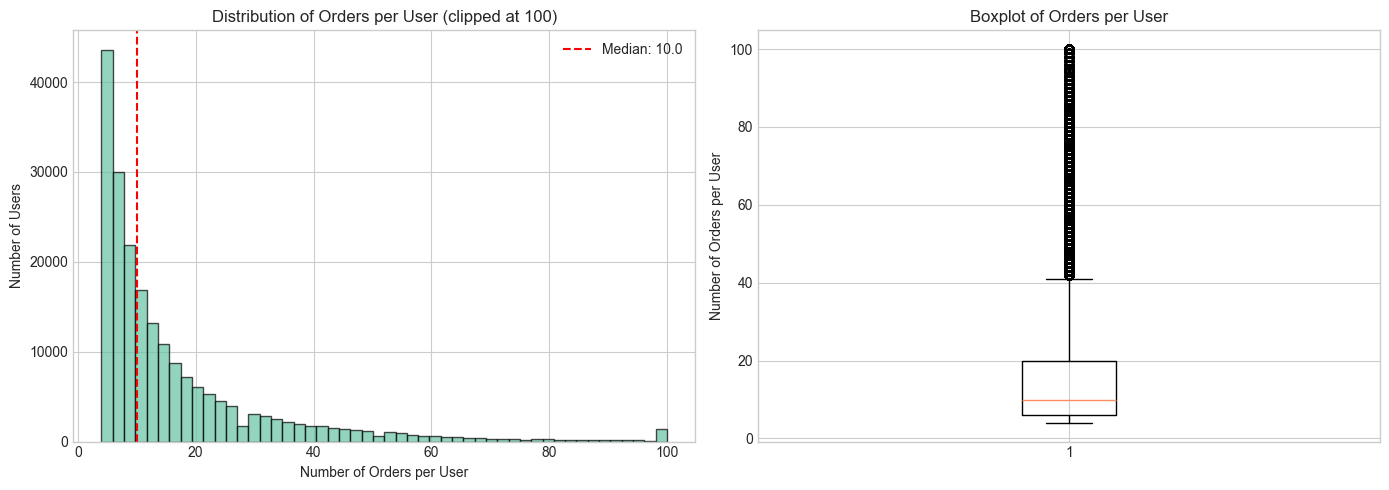

In [25]:

print("\n" + "="*60)
print("5. EDA: Orders per User")
print("="*60)

orders_per_user = orders.groupby('user_id')['order_id'].count()
print(f"Orders per user - min: {orders_per_user.min()}, "
      f"max: {orders_per_user.max()}, "
      f"mean: {orders_per_user.mean():.2f}, "
      f"median: {orders_per_user.median():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
orders_per_user_clipped = orders_per_user[orders_per_user <= 100]
axes[0].hist(orders_per_user_clipped, bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Number of Orders per User')
axes[0].set_ylabel('Number of Users')
axes[0].set_title('Distribution of Orders per User (clipped at 100)')
axes[0].axvline(orders_per_user.median(), color='red', linestyle='--', label=f'Median: {orders_per_user.median():.1f}')
axes[0].legend()

axes[1].boxplot(orders_per_user, vert=True)
axes[1].set_ylabel('Number of Orders per User')
axes[1].set_title('Boxplot of Orders per User')
plt.tight_layout()
plt.savefig('eda_orders_per_user.png', dpi=150)
plt.show()



6. EDA: Basket Size (items per order)
Basket size - min: 1, max: 145, mean: 10.09, median: 8.00


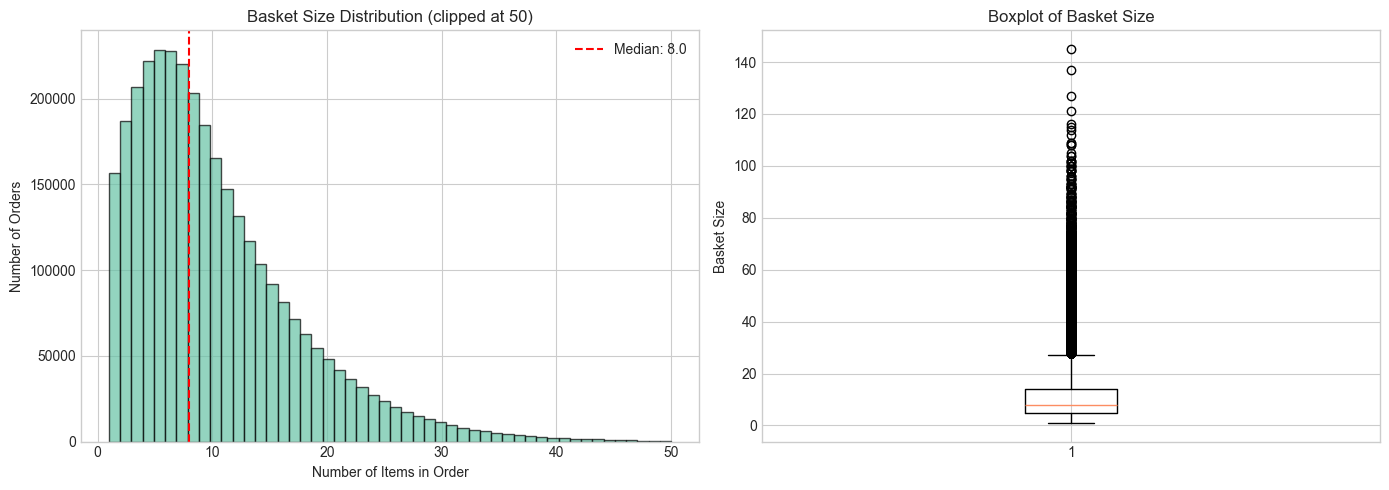

In [26]:

print("\n" + "="*60)
print("6. EDA: Basket Size (items per order)")
print("="*60)

basket_size = prior_merged.groupby('order_id')['product_id'].count()
print(f"Basket size - min: {basket_size.min()}, "
      f"max: {basket_size.max()}, "
      f"mean: {basket_size.mean():.2f}, "
      f"median: {basket_size.median():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
basket_clipped = basket_size[basket_size <= 50]
axes[0].hist(basket_clipped, bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Number of Items in Order')
axes[0].set_ylabel('Number of Orders')
axes[0].set_title('Basket Size Distribution (clipped at 50)')
axes[0].axvline(basket_size.median(), color='red', linestyle='--', label=f'Median: {basket_size.median():.1f}')
axes[0].legend()

axes[1].boxplot(basket_size, vert=True)
axes[1].set_ylabel('Basket Size')
axes[1].set_title('Boxplot of Basket Size')
plt.tight_layout()
plt.savefig('eda_basket_size.png', dpi=150)
plt.show()


This script analyzes the reorder rate and class imbalance in the dataset. It calculates the global reorder rate for both prior and train orders, then shows the class distribution (reordered vs not reordered) with an imbalance ratio. It visualizes the imbalance using a pie chart and a bar plot, saving the figure as 'eda_class_imbalance.png'.


7. EDA: Reorder Rate and Class Imbalance
Global reorder rate (prior orders): 0.5897 (58.97%)
Global reorder rate (train orders): 0.5986 (59.86%)

Class distribution (prior):
reordered
1    19126536
0    13307953
Name: count, dtype: int64
Imbalance ratio (0:1): 0.70


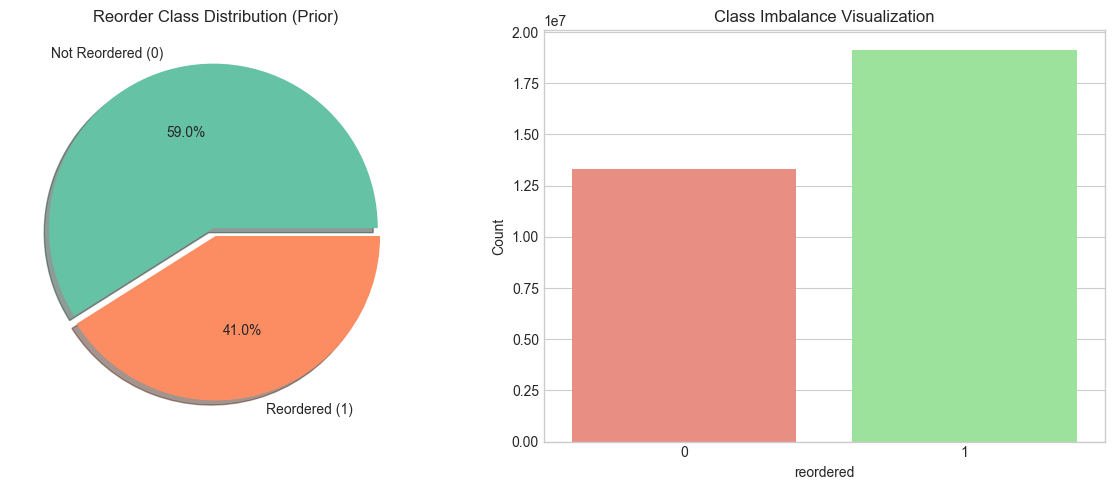

In [12]:

print("\n" + "="*60)
print("7. EDA: Reorder Rate and Class Imbalance")
print("="*60)

global_reorder_rate = prior_merged['reordered'].mean()
print(f"Global reorder rate (prior orders): {global_reorder_rate:.4f} ({global_reorder_rate*100:.2f}%)")

train_merged = order_products_train.merge(orders, on='order_id', how='left')
train_reorder_rate = train_merged['reordered'].mean()
print(f"Global reorder rate (train orders): {train_reorder_rate:.4f} ({train_reorder_rate*100:.2f}%)")

print("\nClass distribution (prior):")
class_counts = prior_merged['reordered'].value_counts()
print(class_counts)
print(f"Imbalance ratio (0:1): {class_counts[0]/class_counts[1]:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].pie(class_counts, labels=['Not Reordered (0)', 'Reordered (1)'], 
            autopct='%1.1f%%', explode=[0.05, 0], shadow=True)
axes[0].set_title('Reorder Class Distribution (Prior)')

sns.barplot(x=class_counts.index, y=class_counts.values, ax=axes[1], palette=['salmon', 'lightgreen'])
axes[1].set_xlabel('reordered')
axes[1].set_ylabel('Count')
axes[1].set_title('Class Imbalance Visualization')
plt.tight_layout()
plt.savefig('eda_class_imbalance.png', dpi=150)
plt.show()

This script analyzes product popularity and long-tail behavior. It computes purchase counts per product, displays the top 10 most popular products, and visualizes the popularity distribution on both linear and log-log scales (revealing a long-tail pattern). It also quantifies the concentration by showing that the top 20% of products account for a large percentage of all purchases.


8. EDA: Product Popularity and Long-tail Behavior
Top 10 most popular products:
product_name
Banana                    472565
Bag of Organic Bananas    379450
Organic Strawberries      264683
Organic Baby Spinach      241921
Organic Hass Avocado      213584
Organic Avocado           176815
Large Lemon               152657
Strawberries              142951
Limes                     140627
Organic Whole Milk        137905
Name: order_id, dtype: int64


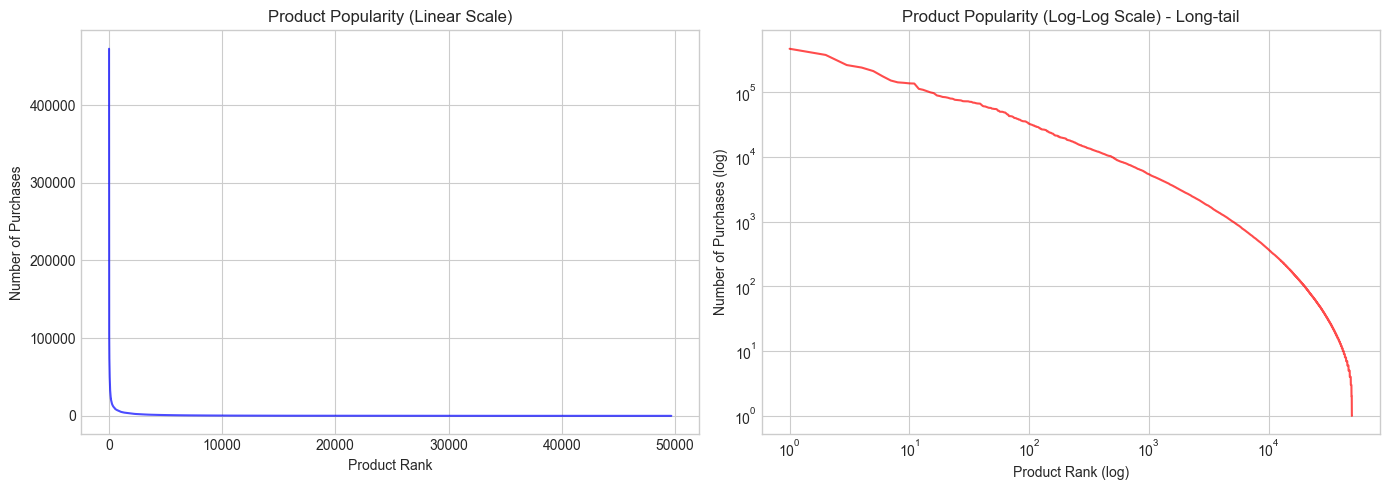

Top 20% products account for 91.0% of all purchases


In [27]:

print("\n" + "="*60)
print("8. EDA: Product Popularity and Long-tail Behavior")
print("="*60)

product_popularity = prior_merged.groupby('product_id')['order_id'].count().sort_values(ascending=False)
product_popularity.name = 'purchase_count'

print(f"Top 10 most popular products:")
print(prior_merged.groupby('product_name')['order_id'].count().sort_values(ascending=False).head(10))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(range(1, len(product_popularity)+1), product_popularity.values, 'b-', alpha=0.7)
axes[0].set_xlabel('Product Rank')
axes[0].set_ylabel('Number of Purchases')
axes[0].set_title('Product Popularity (Linear Scale)')
axes[1].loglog(range(1, len(product_popularity)+1), product_popularity.values, 'r-', alpha=0.7)
axes[1].set_xlabel('Product Rank (log)')
axes[1].set_ylabel('Number of Purchases (log)')
axes[1].set_title('Product Popularity (Log-Log Scale) - Long-tail')
plt.tight_layout()
plt.savefig('eda_product_popularity.png', dpi=150)
plt.show()

top_20_pct = int(0.2 * len(product_popularity))
purchases_top20 = product_popularity.head(top_20_pct).sum()
total_purchases = product_popularity.sum()
print(f"Top 20% products account for {purchases_top20/total_purchases*100:.1f}% of all purchases")


This script analyzes the distribution of orders across departments and aisles. It displays the top 10 departments and top 10 aisles by order count, then visualizes them as horizontal bar charts. The plot is saved as 'eda_dept_aisle.png'.


9. EDA: Department and Aisle Distributions
Top 10 departments:
department
produce            9479291
dairy eggs         5414016
snacks             2887550
beverages          2690129
frozen             2236432
pantry             1875577
bakery             1176787
canned goods       1068058
deli               1051249
dry goods pasta     866627
Name: count, dtype: int64

Top 10 aisles:
aisle
fresh fruits                     3642188
fresh vegetables                 3418021
packaged vegetables fruits       1765313
yogurt                           1452343
packaged cheese                   979763
milk                              891015
water seltzer sparkling water     841533
chips pretzels                    722470
soy lactosefree                   638253
bread                             584834
Name: count, dtype: int64


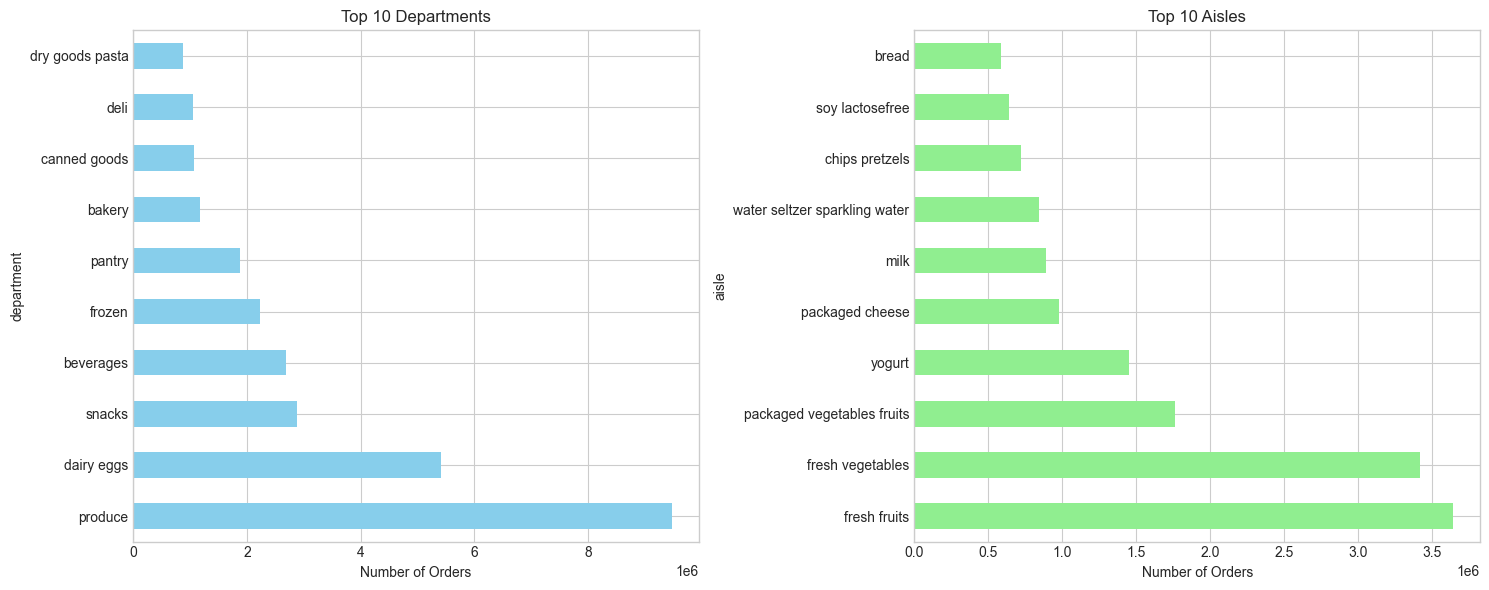

In [28]:

print("\n" + "="*60)
print("9. EDA: Department and Aisle Distributions")
print("="*60)

dept_counts = prior_merged['department'].value_counts()
aisle_counts = prior_merged['aisle'].value_counts()

print("Top 10 departments:")
print(dept_counts.head(10))
print("\nTop 10 aisles:")
print(aisle_counts.head(10))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
dept_counts.head(10).plot(kind='barh', ax=axes[0], color='skyblue')
axes[0].set_xlabel('Number of Orders')
axes[0].set_title('Top 10 Departments')

aisle_counts.head(10).plot(kind='barh', ax=axes[1], color='lightgreen')
axes[1].set_xlabel('Number of Orders')
axes[1].set_title('Top 10 Aisles')
plt.tight_layout()
plt.savefig('eda_dept_aisle.png', dpi=150)
plt.show()


This script performs correlation analysis on order features (order number, day of week, hour of day, days since prior order) after filling missing values with the mean. It then calculates and visualizes reorder rates by day of week and hour of day, showing how reorder behavior varies across time. The plot is saved as 'eda_reorder_by_time.png'.


10. EDA: Correlation Analysis
Correlation matrix:
                        order_number  order_dow  order_hour_of_day  \
order_number                1.000000   0.015258          -0.035690   
order_dow                   0.015258   1.000000           0.005978   
order_hour_of_day          -0.035690   0.005978           1.000000   
days_since_prior_order     -0.350836  -0.027221           0.001252   

                        days_since_prior_order  
order_number                         -0.350836  
order_dow                            -0.027221  
order_hour_of_day                     0.001252  
days_since_prior_order                1.000000  


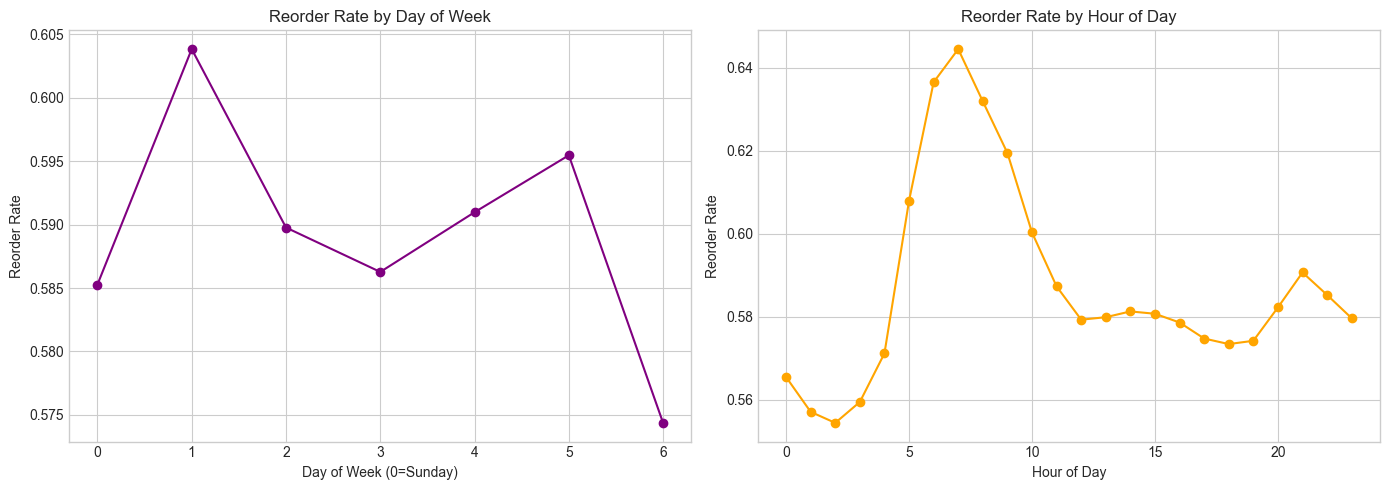

In [15]:

print("\n" + "="*60)
print("10. EDA: Correlation Analysis")
print("="*60)


orders_filled = orders.copy()
orders_filled['days_since_prior_order'] = orders_filled['days_since_prior_order'].fillna(orders_filled['days_since_prior_order'].mean())


corr_vars = orders_filled[['order_number', 'order_dow', 'order_hour_of_day', 'days_since_prior_order']].corr()
print("Correlation matrix:")
print(corr_vars)


prior_with_days = prior_merged.merge(orders_filled[['order_id', 'days_since_prior_order']], on='order_id', how='left')
reorder_by_dow = prior_merged.groupby('order_dow')['reordered'].mean()
reorder_by_hour = prior_merged.groupby('order_hour_of_day')['reordered'].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(reorder_by_dow.index, reorder_by_dow.values, 'o-', color='purple')
axes[0].set_xlabel('Day of Week (0=Sunday)')
axes[0].set_ylabel('Reorder Rate')
axes[0].set_title('Reorder Rate by Day of Week')

axes[1].plot(reorder_by_hour.index, reorder_by_hour.values, 'o-', color='orange')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Reorder Rate')
axes[1].set_title('Reorder Rate by Hour of Day')
plt.tight_layout()
plt.savefig('eda_reorder_by_time.png', dpi=150)
plt.show()


This script handles missing values and outliers in the orders data. It fills missing 'days_since_prior_order' values with the median, then detects basket size outliers using the IQR method (1.5× rule), reporting the number and percentage of outlier orders along with the outlier bounds.

In [29]:

print("\n" + "="*60)
print("11. Data Quality: Missing Values & Outliers Handling")
print("="*60)

print("Missing values before handling:")
print(orders.isnull().sum())
median_days = orders['days_since_prior_order'].median()
orders['days_since_prior_order'].fillna(median_days, inplace=True)
print(f"\nFilled NaN with median: {median_days}")
print("Missing values after handling:")
print(orders.isnull().sum())


Q1 = basket_size.quantile(0.25)
Q3 = basket_size.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR
outliers = basket_size[(basket_size < lower_bound) | (basket_size > upper_bound)]
print(f"\nBasket size outliers: {len(outliers)} orders ({len(outliers)/len(basket_size)*100:.2f}%)")
print(f"Outlier bounds: [{lower_bound:.0f}, {upper_bound:.0f}]")




11. Data Quality: Missing Values & Outliers Handling
Missing values before handling:
order_id                       0
user_id                        0
eval_set                       0
order_number                   0
order_dow                      0
order_hour_of_day              0
days_since_prior_order    206209
dtype: int64

Filled NaN with median: 7.0
Missing values after handling:
order_id                  0
user_id                   0
eval_set                  0
order_number              0
order_dow                 0
order_hour_of_day         0
days_since_prior_order    0
dtype: int64

Basket size outliers: 105058 orders (3.27%)
Outlier bounds: [-8, 28]


This script creates user-level feature aggregations from prior orders. It computes for each user: total order count, mean/std of days between orders, average basket size, reorder ratio, and days since last prior order (filling missing with 0). The features are merged into a single user_features DataFrame.

In [30]:

user_features = orders[orders['eval_set'] == 'prior'].groupby('user_id').agg({
    'order_id': 'count',  # total orders
    'days_since_prior_order': ['mean', 'std']  # avg time between orders
}).reset_index()
user_features.columns = ['user_id', 'user_total_orders', 'user_avg_days_between_orders', 'user_std_days_between_orders']


user_basket_size = prior_merged.groupby(['user_id', 'order_id'])['product_id'].count().reset_index()
user_basket_avg = user_basket_size.groupby('user_id')['product_id'].mean().reset_index()
user_basket_avg.columns = ['user_id', 'user_avg_basket_size']
user_features = user_features.merge(user_basket_avg, on='user_id', how='left')

user_reorder_ratio = prior_merged.groupby('user_id')['reordered'].mean().reset_index()
user_reorder_ratio.columns = ['user_id', 'user_reorder_ratio']
user_features = user_features.merge(user_reorder_ratio, on='user_id', how='left')

last_prior_order = orders[orders['eval_set'] == 'prior'].groupby('user_id')['order_number'].max().reset_index()
last_prior_order = last_prior_order.merge(orders[['user_id', 'order_number', 'days_since_prior_order']], 
                                           on=['user_id', 'order_number'], how='left')
last_prior_order = last_prior_order.rename(columns={'days_since_prior_order': 'user_days_since_last_prior_order'})
user_features = user_features.merge(last_prior_order[['user_id', 'user_days_since_last_prior_order']], on='user_id', how='left')
user_features['user_days_since_last_prior_order'].fillna(0, inplace=True)  

print("User-level features created:", list(user_features.columns))

User-level features created: ['user_id', 'user_total_orders', 'user_avg_days_between_orders', 'user_std_days_between_orders', 'user_avg_basket_size', 'user_reorder_ratio', 'user_days_since_last_prior_order']


This script creates product-level features from prior orders. It computes for each product: total purchase count, global reorder rate, popularity score (percentile rank), and average order number when purchased (recency). The features are merged into a product_features DataFrame.

In [31]:

product_features = prior_merged.groupby('product_id').agg({
    'order_id': 'count',  
    'reordered': 'mean'   
}).reset_index()
product_features.columns = ['product_id', 'product_total_purchases', 'product_global_reorder_rate']

product_features['product_popularity_score'] = product_features['product_total_purchases'].rank(pct=True)

product_recency = prior_merged.groupby('product_id')['order_number'].mean().reset_index()
product_recency.columns = ['product_id', 'product_avg_order_number_last_purchase']
product_features = product_features.merge(product_recency, on='product_id', how='left')

print("Product-level features created:", list(product_features.columns))


Product-level features created: ['product_id', 'product_total_purchases', 'product_global_reorder_rate', 'product_popularity_score', 'product_avg_order_number_last_purchase']


This script creates user-product level interaction features from prior orders. It computes for each (user, product) pair: interaction count, last order number, reorder rate, product share within user's total purchases, and recency (orders since last purchase). Missing values are filled (shares with 0, recency with 99). The final up_features DataFrame contains temporal and behavioral features for collaborative filtering-style modeling.

In [32]:

user_product_prior = prior_merged[['user_id', 'product_id', 'order_id', 'order_number', 'reordered']].copy()
user_product_prior = user_product_prior.sort_values(['user_id', 'order_number'])

print("Step 1: Base data created")
print(f"Shape: {user_product_prior.shape}")

up_features = user_product_prior.groupby(['user_id', 'product_id']).agg({
    'order_number': ['count', 'max'],  
    'reordered': 'mean'                
}).reset_index()

up_features.columns = ['user_id', 'product_id', 'up_interaction_count', 'up_last_order_number', 'up_user_product_reorder_rate']

print(f"\nStep 2: User-Product features shape: {up_features.shape}")
print(up_features.head(3))


user_total_items = prior_merged.groupby('user_id')['product_id'].count().reset_index()
user_total_items.columns = ['user_id', 'user_total_items']

product_user_counts = prior_merged.groupby(['user_id', 'product_id']).size().reset_index(name='up_count')

product_user_counts = product_user_counts.merge(user_total_items, on='user_id', how='left')
product_user_counts['up_product_share'] = product_user_counts['up_count'] / product_user_counts['user_total_items']

up_features = up_features.merge(
    product_user_counts[['user_id', 'product_id', 'up_product_share']], 
    on=['user_id', 'product_id'], 
    how='left'
)

print(f"\nStep 3: After product share merge: {up_features.shape}")
print(f"Columns now: {up_features.columns.tolist()}")


last_order_per_user = orders.groupby('user_id')['order_number'].max().reset_index()
last_order_per_user.columns = ['user_id', 'max_order_number']

up_last_order = user_product_prior.groupby(['user_id', 'product_id'])['order_number'].max().reset_index()
up_last_order.columns = ['user_id', 'product_id', 'up_last_order_number_for_product']

up_recency = up_last_order.merge(last_order_per_user, on='user_id', how='left')

up_recency['up_orders_since_last_purchase'] = (
    up_recency['max_order_number'] - up_recency['up_last_order_number_for_product']
)

up_features = up_features.merge(
    up_recency[['user_id', 'product_id', 'up_orders_since_last_purchase']], 
    on=['user_id', 'product_id'], 
    how='left'
)

print(f"\nStep 4: After temporal features merge: {up_features.shape}")
print(f"Final columns: {up_features.columns.tolist()}")


up_features['up_product_share'] = up_features['up_product_share'].fillna(0)
up_features['up_orders_since_last_purchase'] = up_features['up_orders_since_last_purchase'].fillna(99)

print("\nStep 5: NaN values filled")
print(f"✓ User-Product features ready! Final shape: {up_features.shape}")
print("\nSample of final up_features:")
print(up_features.head(5))

Step 1: Base data created
Shape: (32434489, 5)

Step 2: User-Product features shape: (13307953, 5)
   user_id  product_id  up_interaction_count  up_last_order_number  \
0        1         196                    10                    10   
1        1       10258                     9                    10   
2        1       10326                     1                     5   

   up_user_product_reorder_rate  
0                      0.900000  
1                      0.888889  
2                      0.000000  

Step 3: After product share merge: (13307953, 6)
Columns now: ['user_id', 'product_id', 'up_interaction_count', 'up_last_order_number', 'up_user_product_reorder_rate', 'up_product_share']

Step 4: After temporal features merge: (13307953, 7)
Final columns: ['user_id', 'product_id', 'up_interaction_count', 'up_last_order_number', 'up_user_product_reorder_rate', 'up_product_share', 'up_orders_since_last_purchase']

Step 5: NaN values filled
✓ User-Product features ready! Final sha

This script merges all created features into a final training dataset. It starts with train order-product pairs, then left-joins user_features, product_features, and user-product features. Missing values are filled with defaults (zeros, median values, or 99 for recency). The final feature set is saved as 'instacart_features_phase1.csv'.

In [33]:


train_orders_users = order_products_train[['order_id', 'product_id']].merge(
    orders[['order_id', 'user_id']], on='order_id', how='left'
)

final_features = train_orders_users.merge(user_features, on='user_id', how='left')
final_features = final_features.merge(product_features, on='product_id', how='left')
final_features = final_features.merge(up_features, on=['user_id', 'product_id'], how='left')

final_features = final_features.merge(order_products_train[['order_id', 'product_id', 'reordered']], 
                                      on=['order_id', 'product_id'], how='left')

final_features.fillna({
    'up_interaction_count': 0,
    'up_user_product_reorder_rate': 0,
    'up_product_share': 0,
    'up_orders_since_last_purchase': 99,  # large number meaning never/very long ago
    'user_avg_days_between_orders': user_features['user_avg_days_between_orders'].median(),
    'user_std_days_between_orders': 0,
    'product_avg_order_number_last_purchase': product_features['product_avg_order_number_last_purchase'].median()
}, inplace=True)

print(f"\nFinal feature set shape: {final_features.shape}")
print("Columns in final feature set:")
print(final_features.columns.tolist())

final_features.to_csv('instacart_features_phase1.csv', index=False)
print("\nFeatures saved to 'instacart_features_phase1.csv'")



Final feature set shape: (1384617, 19)
Columns in final feature set:
['order_id', 'product_id', 'user_id', 'user_total_orders', 'user_avg_days_between_orders', 'user_std_days_between_orders', 'user_avg_basket_size', 'user_reorder_ratio', 'user_days_since_last_prior_order', 'product_total_purchases', 'product_global_reorder_rate', 'product_popularity_score', 'product_avg_order_number_last_purchase', 'up_interaction_count', 'up_last_order_number', 'up_user_product_reorder_rate', 'up_product_share', 'up_orders_since_last_purchase', 'reordered']

Features saved to 'instacart_features_phase1.csv'


In [34]:

print("\n" + "="*60)
print("13. Quick Correlation with Target (for feature selection hint)")
print("="*60)

numeric_cols = final_features.select_dtypes(include=[np.number]).columns
target_corr = final_features[numeric_cols].corr()['reordered'].sort_values(ascending=False)
print("Top features correlated with reordered:")
print(target_corr.head(15))



13. Quick Correlation with Target (for feature selection hint)
Top features correlated with reordered:
reordered                                 1.000000
up_user_product_reorder_rate              0.677582
up_interaction_count                      0.433668
up_product_share                          0.412855
user_reorder_ratio                        0.342319
product_global_reorder_rate               0.303946
user_total_orders                         0.223947
product_popularity_score                  0.154017
product_total_purchases                   0.152626
user_avg_basket_size                      0.120444
product_avg_order_number_last_purchase    0.078153
product_id                                0.006560
order_id                                  0.001418
user_id                                  -0.004316
user_days_since_last_prior_order         -0.134560
Name: reordered, dtype: float64


In [35]:


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (12, 6)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)



In [36]:



df_features = pd.read_csv('instacart_features_phase1.csv')
print(f"Original feature set shape: {df_features.shape}")

user_cols = [col for col in df_features.columns if col.startswith('user_')]
print(f"\nUser-level columns found: {user_cols}")


user_features = df_features[['user_id'] + user_cols].drop_duplicates(subset=['user_id'])
print(f"\nUser-level feature matrix shape: {user_features.shape}")
print(f"Number of unique users: {user_features.shape[0]}")

print("\nMissing values per user feature:")
print(user_features[user_cols].isnull().sum())

for col in user_cols:
    user_features[col].fillna(user_features[col].median(), inplace=True)

print("\n User-level feature matrix ready")


Original feature set shape: (1384617, 19)

User-level columns found: ['user_id', 'user_total_orders', 'user_avg_days_between_orders', 'user_std_days_between_orders', 'user_avg_basket_size', 'user_reorder_ratio', 'user_days_since_last_prior_order']

User-level feature matrix shape: (131209, 8)
Number of unique users: 131209

Missing values per user feature:
user_id                             0
user_id                             0
user_total_orders                   0
user_avg_days_between_orders        0
user_std_days_between_orders        0
user_avg_basket_size                0
user_reorder_ratio                  0
user_days_since_last_prior_order    0
dtype: int64

 User-level feature matrix ready


In [38]:


user_ids = user_features['user_id'].values
X = user_features[user_cols].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Standardized data shape: {X_scaled.shape}")
print(f"Mean after scaling: {X_scaled.mean(axis=0).mean():.10f}")
print(f"Std after scaling: {X_scaled.std(axis=0).mean():.4f}")


SAMPLE_SIZE = 10000  
if X_scaled.shape[0] > SAMPLE_SIZE:
    print(f"\nSampling {SAMPLE_SIZE} users for t-SNE and UMAP (due to computational constraints)...")
    sample_indices = np.random.choice(X_scaled.shape[0], SAMPLE_SIZE, replace=False)
    X_sample = X_scaled[sample_indices]
    user_ids_sample = user_ids[sample_indices]
    user_features_sample = user_features.iloc[sample_indices]
else:
    X_sample = X_scaled
    user_ids_sample = user_ids
    user_features_sample = user_features


Standardized data shape: (131209, 8)
Mean after scaling: -0.0000000000
Std after scaling: 1.0000

Sampling 10000 users for t-SNE and UMAP (due to computational constraints)...


This script performs PCA for dimensionality reduction. It first fits a full PCA to compute explained variance ratios, then determines the components needed for 90% and 95% cumulative variance. It selects min(50, n_95) components and transforms the scaled feature matrix. The output shows variance explained per component and the final transformed shape.

In [39]:

print("\n" + "="*60)
print("3. PCA: Principal Component Analysis")
print("="*60)

pca_full = PCA(random_state=RANDOM_STATE)
X_pca_full = pca_full.fit_transform(X_scaled)

explained_variance_ratio = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

print(f"\nExplained variance ratio for first 10 components:")
for i, var in enumerate(explained_variance_ratio[:10]):
    print(f"  PC{i+1}: {var:.4f} ({var*100:.2f}%)")

print(f"\nCumulative variance for first 10 components:")
for i, cum in enumerate(cumulative_variance[:10]):
    print(f"  First {i+1} components: {cum:.4f} ({cum*100:.2f}%)")

n_90 = np.argmax(cumulative_variance >= 0.90) + 1
n_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"\n Number of components needed for 90% variance: {n_90}")
print(f" Number of components needed for 95% variance: {n_95}")

n_components_pca = min(50, n_95)
print(f" Selected number of components: {n_components_pca}")

pca = PCA(n_components=n_components_pca, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

print(f"\nPCA transformed shape: {X_pca.shape}")



3. PCA: Principal Component Analysis

Explained variance ratio for first 10 components:
  PC1: 0.3819 (38.19%)
  PC2: 0.2500 (25.00%)
  PC3: 0.1276 (12.76%)
  PC4: 0.1107 (11.07%)
  PC5: 0.0583 (5.83%)
  PC6: 0.0461 (4.61%)
  PC7: 0.0254 (2.54%)
  PC8: 0.0000 (0.00%)

Cumulative variance for first 10 components:
  First 1 components: 0.3819 (38.19%)
  First 2 components: 0.6319 (63.19%)
  First 3 components: 0.7595 (75.95%)
  First 4 components: 0.8702 (87.02%)
  First 5 components: 0.9285 (92.85%)
  First 6 components: 0.9746 (97.46%)
  First 7 components: 1.0000 (100.00%)
  First 8 components: 1.0000 (100.00%)

 Number of components needed for 90% variance: 5
 Number of components needed for 95% variance: 6
 Selected number of components: 6

PCA transformed shape: (131209, 6)


This script visualizes PCA results. It creates a scree plot showing explained variance per component, and a cumulative variance plot with 90% and 95% thresholds. Then it generates 2D scatter plots of the first two principal components, colored by user features: total orders, reorder ratio, and average basket size. Both figures are saved as PNG files.

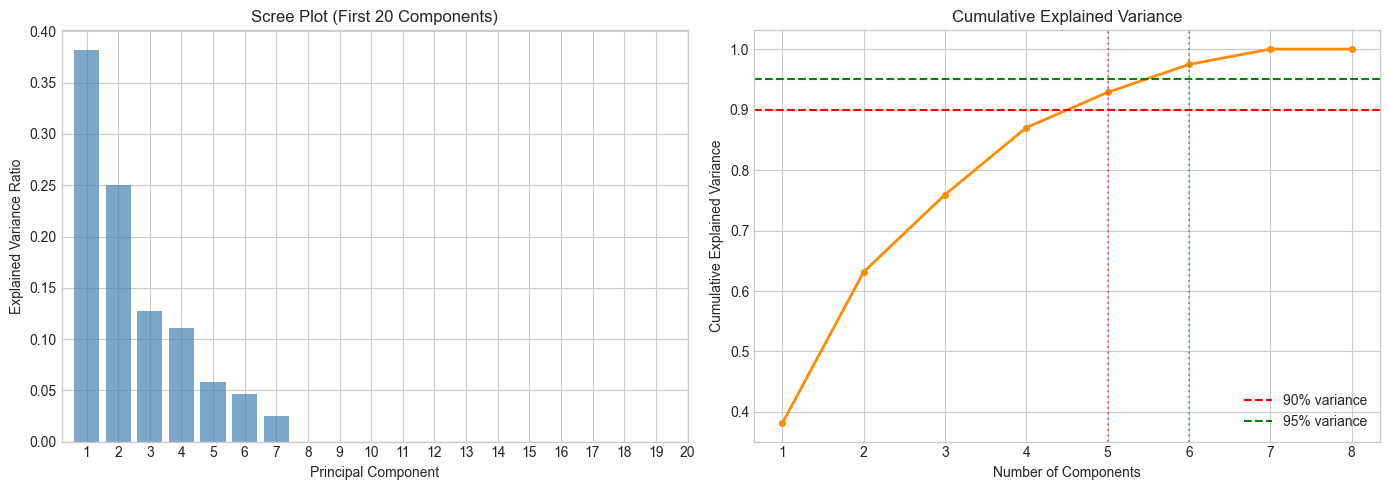

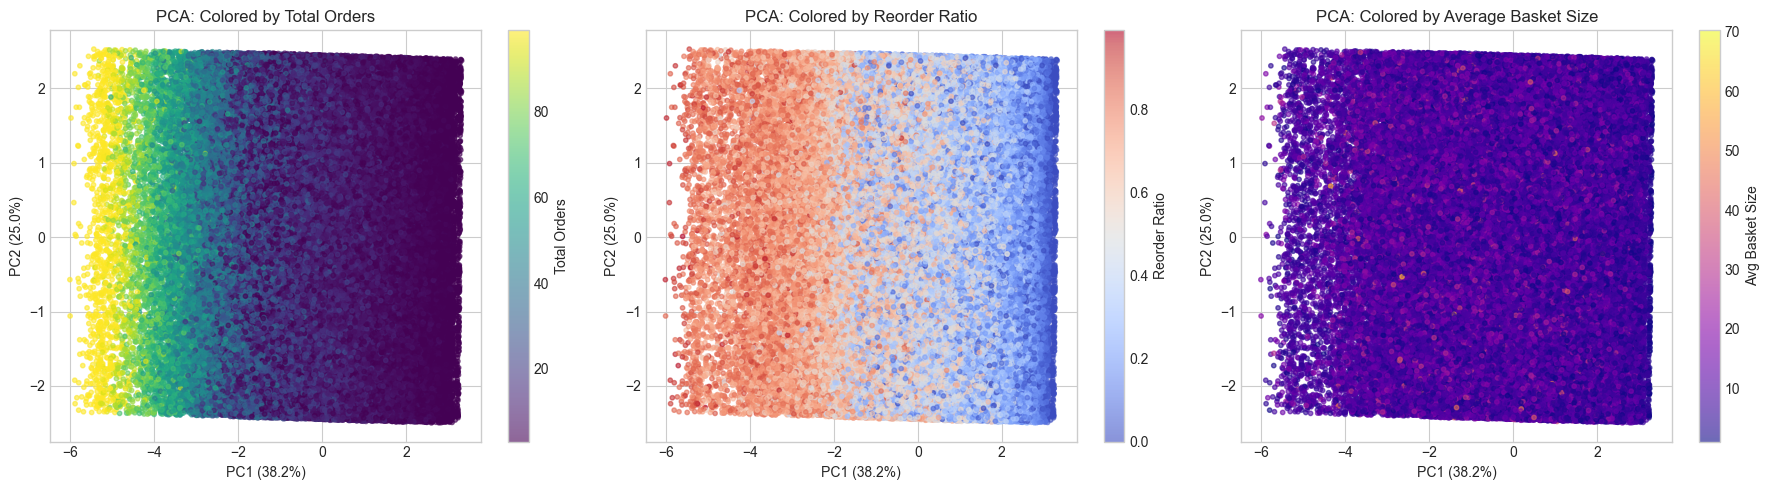

In [46]:


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
axes[0].bar(range(1, len(explained_variance_ratio[:20]) + 1), 
            explained_variance_ratio[:20], alpha=0.7, color='steelblue')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Scree Plot (First 20 Components)')
axes[0].set_xticks(range(1, 21))

axes[1].plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 
             'o-', color='darkorange', linewidth=2, markersize=4)
axes[1].axhline(y=0.90, color='red', linestyle='--', label='90% variance')
axes[1].axhline(y=0.95, color='green', linestyle='--', label='95% variance')
axes[1].axvline(x=n_90, color='red', linestyle=':', alpha=0.5)
axes[1].axvline(x=n_95, color='green', linestyle=':', alpha=0.5)
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('Cumulative Explained Variance')
axes[1].legend()
plt.tight_layout()
plt.savefig('pca_cumulative_variance.png', dpi=150)
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], 
                           c=user_features['user_total_orders'], 
                           cmap='viridis', alpha=0.6, s=10)
axes[0].set_xlabel(f'PC1 ({explained_variance_ratio[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({explained_variance_ratio[1]*100:.1f}%)')
axes[0].set_title('PCA: Colored by Total Orders')
plt.colorbar(scatter1, ax=axes[0], label='Total Orders')

scatter2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], 
                           c=user_features['user_reorder_ratio'], 
                           cmap='coolwarm', alpha=0.6, s=10)
axes[1].set_xlabel(f'PC1 ({explained_variance_ratio[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({explained_variance_ratio[1]*100:.1f}%)')
axes[1].set_title('PCA: Colored by Reorder Ratio')
plt.colorbar(scatter2, ax=axes[1], label='Reorder Ratio')

scatter3 = axes[2].scatter(X_pca[:, 0], X_pca[:, 1], 
                           c=user_features['user_avg_basket_size'], 
                           cmap='plasma', alpha=0.6, s=10)
axes[2].set_xlabel(f'PC1 ({explained_variance_ratio[0]*100:.1f}%)')
axes[2].set_ylabel(f'PC2 ({explained_variance_ratio[1]*100:.1f}%)')
axes[2].set_title('PCA: Colored by Average Basket Size')
plt.colorbar(scatter3, ax=axes[2], label='Avg Basket Size')

plt.tight_layout()
plt.savefig('pca_2d_visualization.png', dpi=150)
plt.show()


This script interprets PCA results by computing and analyzing loadings (feature contributions to principal components). It creates a loadings DataFrame from user features, identifies top positive/negative contributors to PC1 and PC2, and visualizes the most important features in a heatmap showing how they load onto the first several PCs. The heatmap is saved as 'pca_loadings_heatmap.png'. Error handling ensures robustness if feature dimensions don't match.


3.2 Interpreting PCA Loadings...
Number of user-level features: 7
First 5 user columns: ['user_id', 'user_total_orders', 'user_avg_days_between_orders', 'user_std_days_between_orders', 'user_avg_basket_size']
PCA components shape: (6, 8)
X_scaled shape: (131209, 8)

Expected features: 7
Actual features in X_scaled: 8
Actual components in pca: 6
Using 6 components for loadings

✓ Loadings DataFrame created with shape: (7, 6)

----------------------------------------
PC1 Analysis:
----------------------------------------
Top 5 positive contributors to PC1:
  user_std_days_between_orders: 0.4960
  user_avg_basket_size: 0.4775
  user_total_orders: 0.0118
  user_id: 0.0118
  user_reorder_ratio: -0.0560

Top 5 negative contributors to PC1:
  user_total_orders: 0.0118
  user_id: 0.0118
  user_reorder_ratio: -0.0560
  user_days_since_last_prior_order: -0.3965
  user_avg_days_between_orders: -0.4418

----------------------------------------
PC2 Analysis:
---------------------------------------

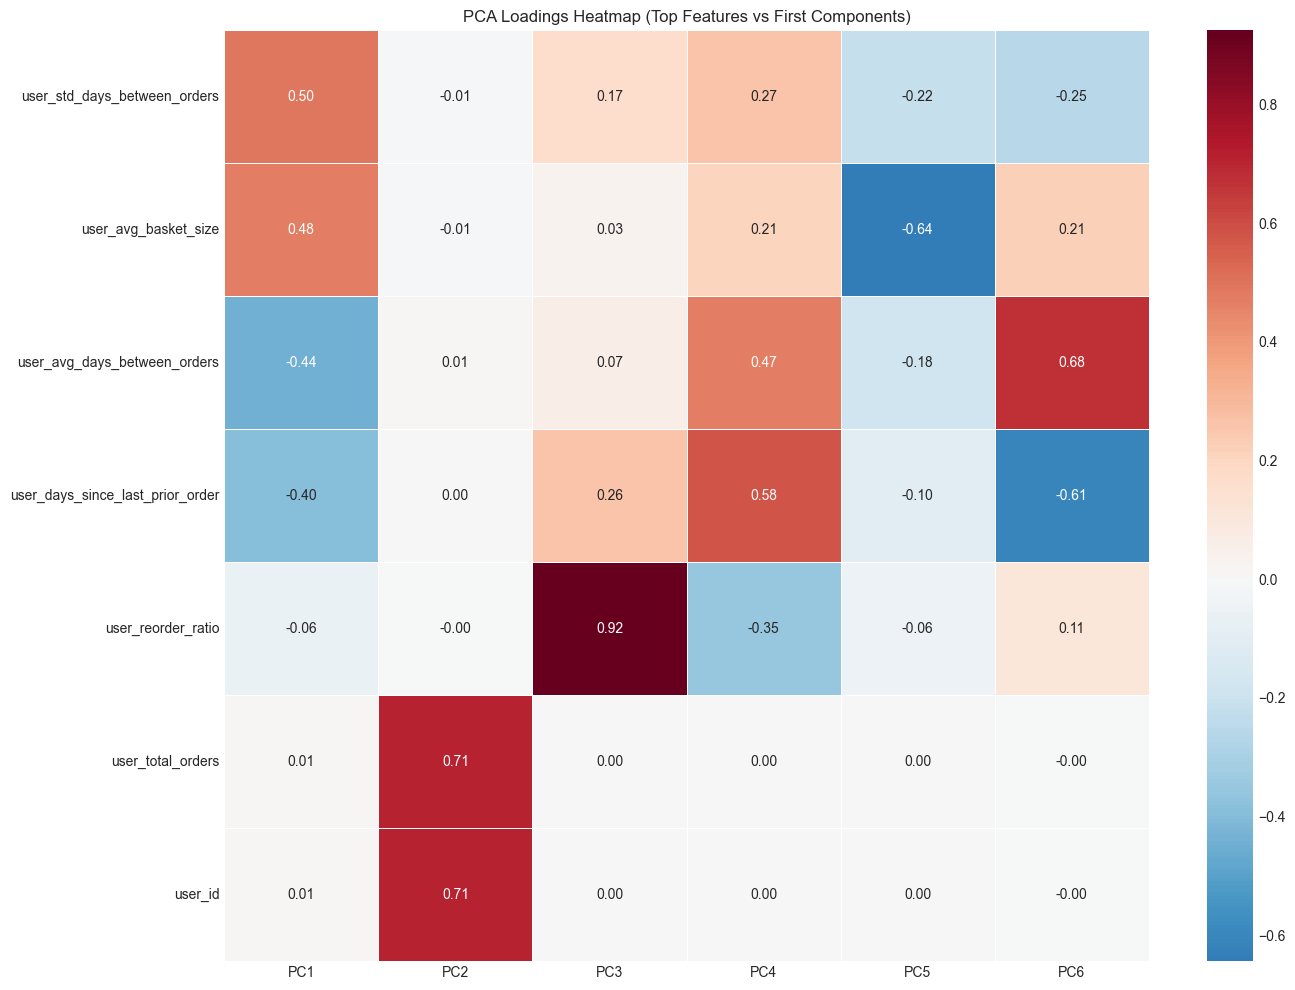


 Heatmap saved as 'pca_loadings_heatmap.png'


In [47]:

print("\n" + "="*60)
print("3.2 Interpreting PCA Loadings...")
print("="*60)

print(f"Number of user-level features: {len(user_cols)}")
print(f"First 5 user columns: {user_cols[:5] if len(user_cols) > 0 else 'None'}")
print(f"PCA components shape: {pca.components_.shape}")
print(f"X_scaled shape: {X_scaled.shape}")

if len(user_cols) == 0:
    print("\n WARNING: No user-level columns found!")
    numeric_cols = user_features.select_dtypes(include=[np.number]).columns.tolist()
    user_cols = [col for col in numeric_cols if col != 'user_id']
    print(f"Using {len(user_cols)} numeric columns as features: {user_cols[:5]}...")


n_features_expected = len(user_cols)
n_features_actual = X_scaled.shape[1]
n_components_actual = pca.components_.shape[0]

print(f"\nExpected features: {n_features_expected}")
print(f"Actual features in X_scaled: {n_features_actual}")
print(f"Actual components in pca: {n_components_actual}")

n_components_for_loadings = min(n_components_actual, n_components_pca, n_features_actual)
print(f"Using {n_components_for_loadings} components for loadings")

try:
    n_features_for_loadings = min(len(user_cols), pca.components_.shape[1])
    features_to_use = user_cols[:n_features_for_loadings]
    
    loadings = pd.DataFrame(
        pca.components_[:n_components_for_loadings, :n_features_for_loadings].T,
        columns=[f'PC{i+1}' for i in range(n_components_for_loadings)],
        index=features_to_use
    )
    print(f"\n✓ Loadings DataFrame created with shape: {loadings.shape}")
    
    if loadings.shape[0] == 0:
        print(" Loadings DataFrame has no rows! Cannot interpret PCA.")
    else:
        if 'PC1' in loadings.columns and loadings.shape[0] > 0:
            print("\n" + "-"*40)
            print("PC1 Analysis:")
            print("-"*40)
            pc1_loadings = loadings['PC1'].sort_values(ascending=False)
            print("Top 5 positive contributors to PC1:")
            for feat, val in pc1_loadings.head(5).items():
                print(f"  {feat}: {val:.4f}")
            print("\nTop 5 negative contributors to PC1:")
            for feat, val in pc1_loadings.tail(5).items():
                print(f"  {feat}: {val:.4f}")
        else:
            print("\n PC1 not available in loadings")
            pc1_loadings = None
        
        if 'PC2' in loadings.columns and loadings.shape[1] >= 2 and loadings.shape[0] > 0:
            print("\n" + "-"*40)
            print("PC2 Analysis:")
            print("-"*40)
            pc2_loadings = loadings['PC2'].sort_values(ascending=False)
            print("Top 5 positive contributors to PC2:")
            for feat, val in pc2_loadings.head(5).items():
                print(f"  {feat}: {val:.4f}")
            print("\nTop 5 negative contributors to PC2:")
            for feat, val in pc2_loadings.tail(5).items():
                print(f"  {feat}: {val:.4f}")
        else:
            print("\n PC2 not available in loadings")
            pc2_loadings = None
        
        if loadings.shape[0] >= 2 and loadings.shape[1] >= 2:
            try:
                fig, ax = plt.subplots(figsize=(14, 10))
                
                if 'PC1' in loadings.columns:
                    important_features = list(loadings['PC1'].abs().sort_values(ascending=False).head(10).index)
                else:
                    important_features = loadings.index[:min(10, len(loadings.index))].tolist()
                
                n_comp_heatmap = min(8, loadings.shape[1])
                comp_columns = [f'PC{i+1}' for i in range(n_comp_heatmap)]
                
                loadings_top = loadings.loc[important_features, comp_columns]
                
                if loadings_top.shape[0] > 0 and loadings_top.shape[1] > 0:
                    sns.heatmap(loadings_top, annot=True, fmt='.2f', cmap='RdBu_r', 
                               center=0, linewidths=0.5, ax=ax)
                    ax.set_title('PCA Loadings Heatmap (Top Features vs First Components)')
                    plt.tight_layout()
                    plt.savefig('pca_loadings_heatmap.png', dpi=150)
                    plt.show()
                    print("\n Heatmap saved as 'pca_loadings_heatmap.png'")
                else:
                    print("\n Not enough data for heatmap")
                    
            except Exception as e:
                print(f"\n Could not create heatmap: {e}")
        else:
            print("\n Loadings DataFrame too small for heatmap")
            
except Exception as e:
    print(f"\n Error creating loadings: {e}")
    import traceback
    traceback.print_exc()

This script applies t-SNE for non-linear dimensionality reduction on a sampled dataset. It tests three perplexity values (5, 30, 50) and visualizes the resulting 2D embeddings, coloring points by user_total_orders and user_reorder_ratio. The plot shows how t-SNE separates users based on behavior patterns, with results saved as 'tsne_comparison.png'.


4. t-SNE: t-Distributed Stochastic Neighbor Embedding
  Running t-SNE with perplexity=5...
   t-SNE with perplexity=5 completed
  Running t-SNE with perplexity=30...
   t-SNE with perplexity=30 completed
  Running t-SNE with perplexity=50...
   t-SNE with perplexity=50 completed


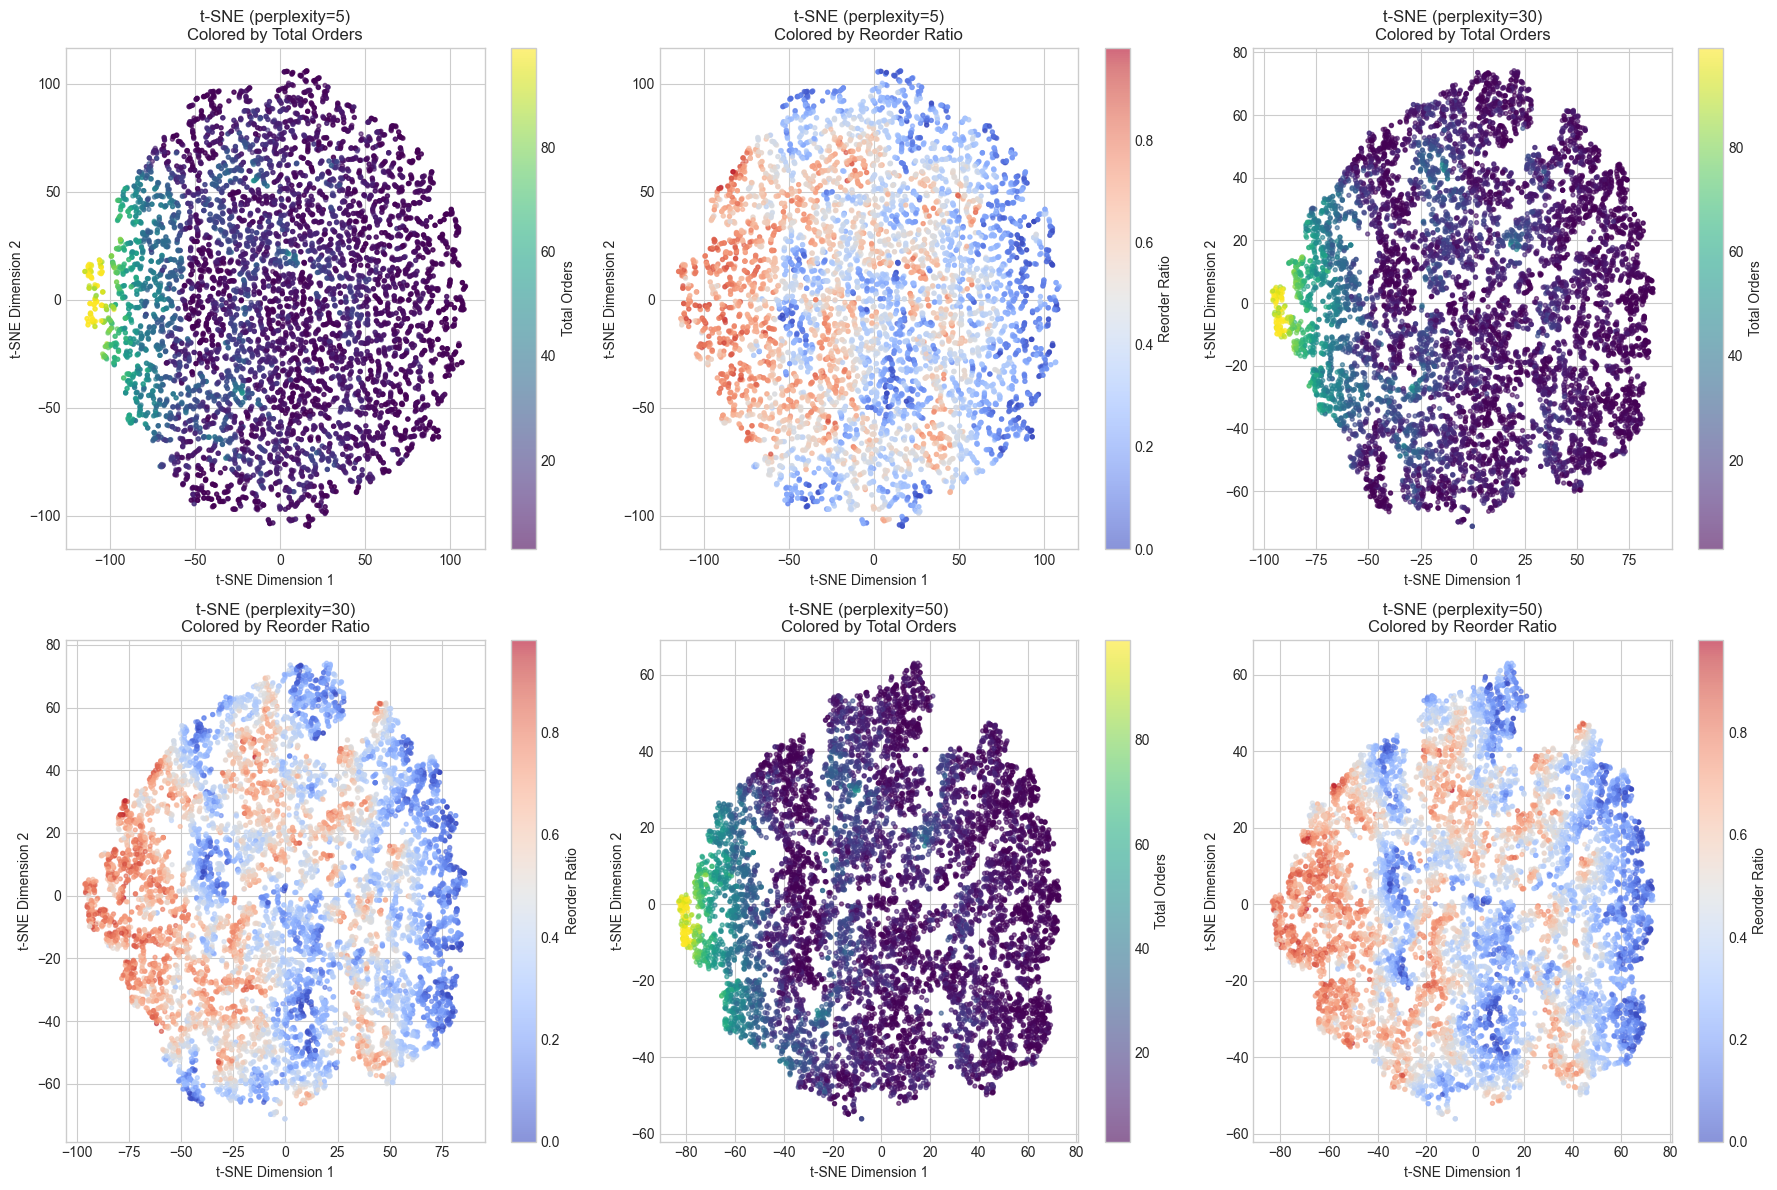

In [49]:

print("\n" + "="*60)
print("4. t-SNE: t-Distributed Stochastic Neighbor Embedding")
print("="*60)

def run_tsne(X, perplexity, random_state=RANDOM_STATE):
    print(f"  Running t-SNE with perplexity={perplexity}...")
    tsne = TSNE(n_components=2, perplexity=perplexity, 
                random_state=random_state, max_iter=1000, 
                learning_rate='auto')
    X_tsne = tsne.fit_transform(X)
    return X_tsne

perplexities = [5, 30, 50]
tsne_results = {}

for perp in perplexities:
    try:
        X_tsne = run_tsne(X_sample, perp)
        tsne_results[perp] = X_tsne
        print(f"   t-SNE with perplexity={perp} completed")
    except Exception as e:
        print(f"   Error with perplexity={perp}: {e}")

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

plot_idx = 0
for perp, X_tsne in tsne_results.items():
    scatter = axes[plot_idx].scatter(X_tsne[:, 0], X_tsne[:, 1], 
                                     c=user_features_sample['user_total_orders'].values,
                                     cmap='viridis', alpha=0.6, s=8)
    axes[plot_idx].set_xlabel('t-SNE Dimension 1')
    axes[plot_idx].set_ylabel('t-SNE Dimension 2')
    axes[plot_idx].set_title(f't-SNE (perplexity={perp})\nColored by Total Orders')
    plt.colorbar(scatter, ax=axes[plot_idx], label='Total Orders')
    plot_idx += 1
    
    scatter = axes[plot_idx].scatter(X_tsne[:, 0], X_tsne[:, 1], 
                                     c=user_features_sample['user_reorder_ratio'].values,
                                     cmap='coolwarm', alpha=0.6, s=8)
    axes[plot_idx].set_xlabel('t-SNE Dimension 1')
    axes[plot_idx].set_ylabel('t-SNE Dimension 2')
    axes[plot_idx].set_title(f't-SNE (perplexity={perp})\nColored by Reorder Ratio')
    plt.colorbar(scatter, ax=axes[plot_idx], label='Reorder Ratio')
    plot_idx += 1

plt.tight_layout()
plt.savefig('tsne_comparison.png', dpi=150)
plt.show()


This script attempts to install and run UMAP for nonlinear dimensionality reduction, with fallback handling if installation fails. It tests multiple UMAP configurations (varying n_neighbors and min_dist), visualizes results colored by user_total_orders and user_reorder_ratio, and then compares PCA, t-SNE (perplexity=30), and UMAP side-by-side. If UMAP is unavailable, it provides theoretical notes and falls back to comparing only PCA and t-SNE. All comparison plots are saved as PNG files.


5. UMAP: Uniform Manifold Approximation and Projection
 UMAP library already found

Running UMAP with different hyperparameters...
  Running UMAP with n_neighbors=5, min_dist=0.1...
   UMAP with n5_min01 completed
  Running UMAP with n_neighbors=15, min_dist=0.5...
   UMAP with n15_min05 completed
  Running UMAP with n_neighbors=30, min_dist=0.1...
   UMAP with n30_min01 completed
  Running UMAP with n_neighbors=50, min_dist=0.5...
   UMAP with n50_min05 completed


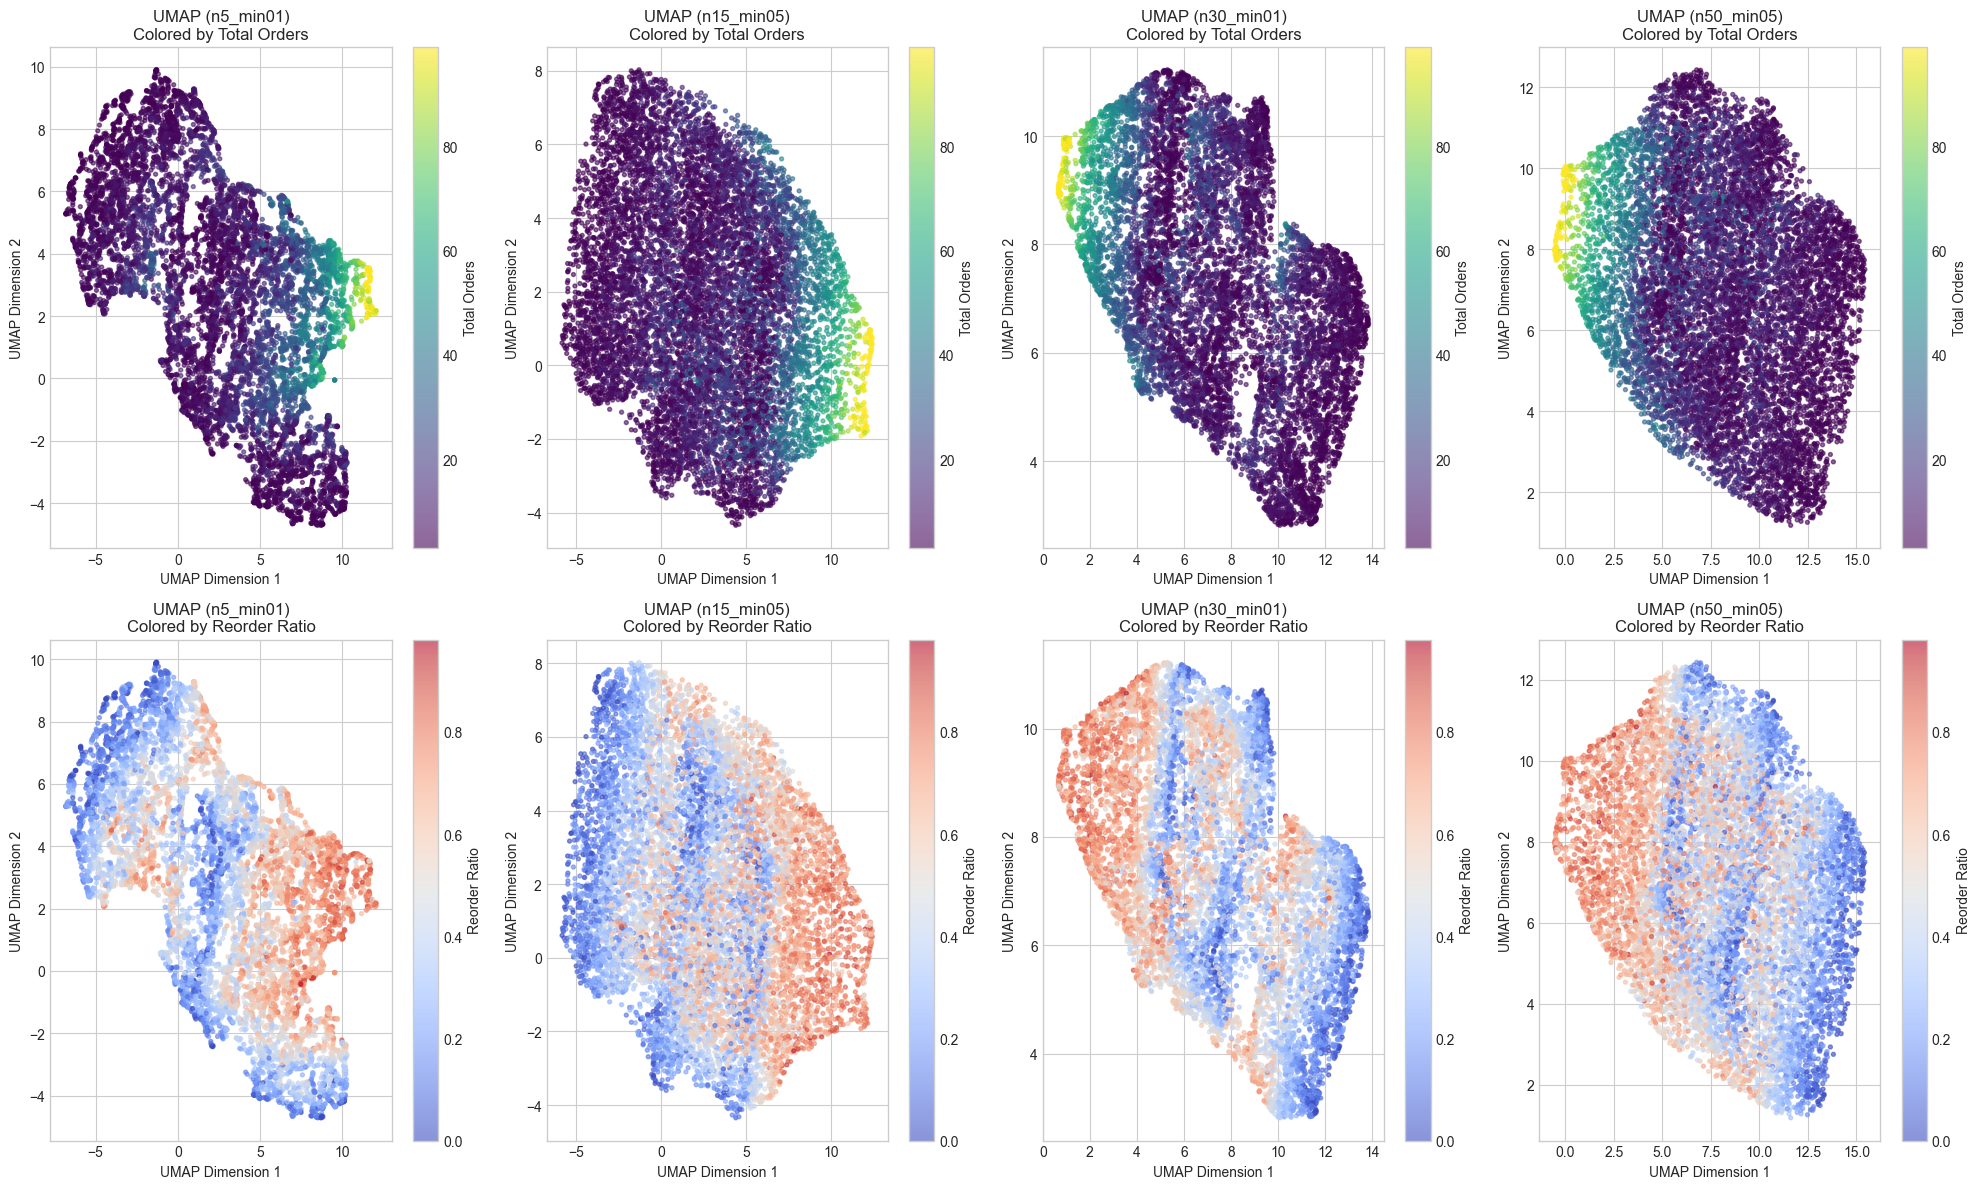


 UMAP comparison plot saved as 'umap_comparison.png'

6. Comparison: PCA vs t-SNE vs UMAP


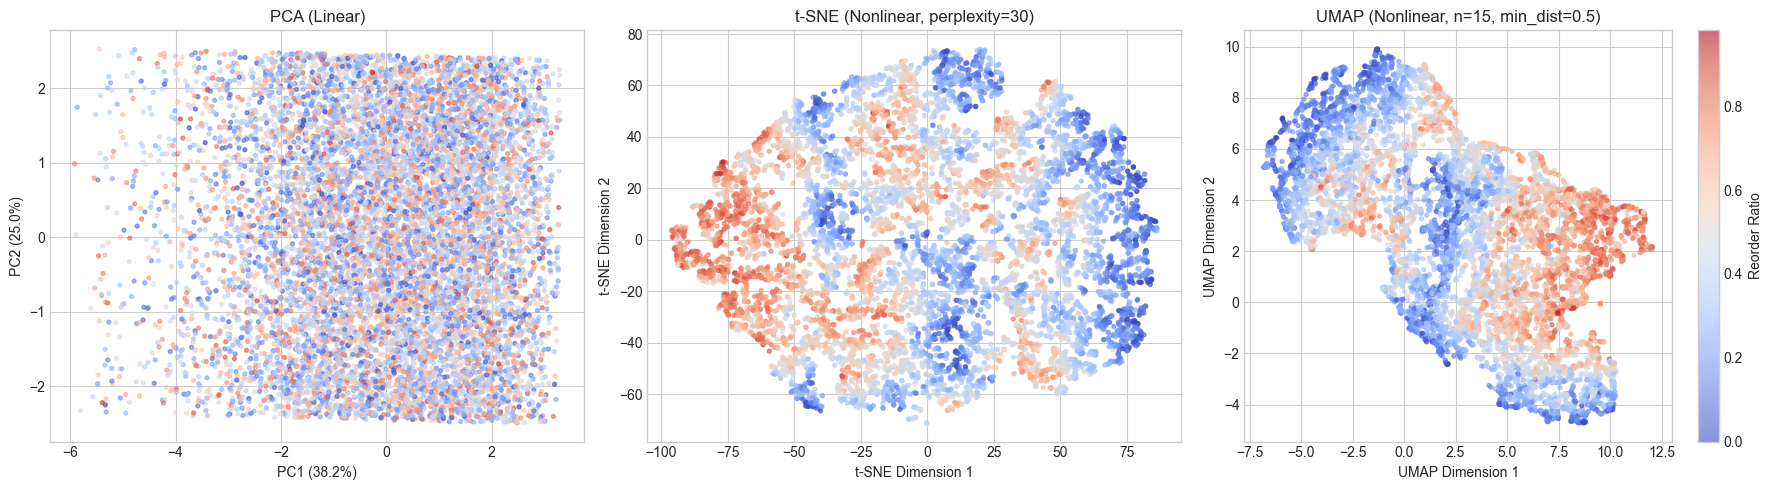


 Comparison plot saved as 'pca_tsne_umap_comparison.png'


In [50]:

print("\n" + "="*60)
print("5. UMAP: Uniform Manifold Approximation and Projection")
print("="*60)

MIRROR_URL = "https://mirror-pypi.runflare.com/simple"

def install_package(package_name):
    import subprocess
    import sys
    try:
        print(f"Installing {package_name} from {MIRROR_URL}...")
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", 
            "-i", MIRROR_URL, 
            package_name
        ])
        print(f" {package_name} installed successfully")
        return True
    except Exception as e:
        print(f"Failed to install {package_name}: {e}")
        return False

umap_available = False

try:
    import umap
    import umap.umap_ as umap_module
    print(" UMAP library already found")
    umap_available = True
except ImportError:
    print("UMAP not found. Attempting to install...")
    
    if install_package("umap-learn"):
        try:
            import umap
            import umap.umap_ as umap_module
            print(" UMAP installed and imported successfully")
            umap_available = True
        except ImportError as e:
            print(f"Still cannot import UMAP after installation: {e}")
            umap_available = False
    else:
        print(" Could not install UMAP")
        umap_available = False

if not umap_available:
    print(" UMAP NOT AVAILABLE - Using alternative approach")
  
    
    umap_results = {}
    best_umap = None
    

    
else:
    print("\nRunning UMAP with different hyperparameters...")
    
    def run_umap(X, n_neighbors, min_dist, random_state=RANDOM_STATE):
        print(f"  Running UMAP with n_neighbors={n_neighbors}, min_dist={min_dist}...")
        umap_reducer = umap.UMAP(n_components=2, n_neighbors=n_neighbors, 
                                  min_dist=min_dist, random_state=random_state,
                                  verbose=False)
        X_umap = umap_reducer.fit_transform(X)
        return X_umap
    
   
    umap_configs = [
        {'n_neighbors': 5, 'min_dist': 0.1, 'name': 'n5_min01'},
        {'n_neighbors': 15, 'min_dist': 0.5, 'name': 'n15_min05'},
        {'n_neighbors': 30, 'min_dist': 0.1, 'name': 'n30_min01'},
        {'n_neighbors': 50, 'min_dist': 0.5, 'name': 'n50_min05'}
    ]
    
    umap_results = {}
    
    for config in umap_configs:
        try:
            X_umap = run_umap(X_sample, config['n_neighbors'], config['min_dist'])
            umap_results[config['name']] = X_umap
            print(f"   UMAP with {config['name']} completed")
        except Exception as e:
            print(f"   Error with {config['name']}: {e}")
    
    if umap_results:
        fig, axes = plt.subplots(2, len(umap_results), figsize=(5*len(umap_results), 12))
        
        if len(umap_results) == 1:
            axes = axes.reshape(2, 1)
        
        plot_idx = 0
        for name, X_umap in umap_results.items():
            scatter = axes[0, plot_idx].scatter(X_umap[:, 0], X_umap[:, 1], 
                                                c=user_features_sample['user_total_orders'].values,
                                                cmap='viridis', alpha=0.6, s=8)
            axes[0, plot_idx].set_xlabel('UMAP Dimension 1')
            axes[0, plot_idx].set_ylabel('UMAP Dimension 2')
            axes[0, plot_idx].set_title(f'UMAP ({name})\nColored by Total Orders')
            plt.colorbar(scatter, ax=axes[0, plot_idx], label='Total Orders')
            
            scatter = axes[1, plot_idx].scatter(X_umap[:, 0], X_umap[:, 1], 
                                                c=user_features_sample['user_reorder_ratio'].values,
                                                cmap='coolwarm', alpha=0.6, s=8)
            axes[1, plot_idx].set_xlabel('UMAP Dimension 1')
            axes[1, plot_idx].set_ylabel('UMAP Dimension 2')
            axes[1, plot_idx].set_title(f'UMAP ({name})\nColored by Reorder Ratio')
            plt.colorbar(scatter, ax=axes[1, plot_idx], label='Reorder Ratio')
            
            plot_idx += 1
        
        plt.tight_layout()
        plt.savefig('umap_comparison.png', dpi=150)
        plt.show()
        print("\n UMAP comparison plot saved as 'umap_comparison.png'")
        
        best_umap = list(umap_results.values())[0] if umap_results else None
    else:
        print("\n No UMAP results generated")
        best_umap = None

print("\n" + "="*60)
print("6. Comparison: PCA vs t-SNE vs UMAP")
print("="*60)

best_tsne = tsne_results.get(30, list(tsne_results.values())[0] if tsne_results else None)

if best_tsne is not None and best_umap is not None:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    axes[0].scatter(X_pca[:len(X_sample), 0], X_pca[:len(X_sample), 1], 
                    c=user_features_sample['user_reorder_ratio'].values,
                    cmap='coolwarm', alpha=0.6, s=8)
    axes[0].set_xlabel(f'PC1 ({explained_variance_ratio[0]*100:.1f}%)')
    axes[0].set_ylabel(f'PC2 ({explained_variance_ratio[1]*100:.1f}%)')
    axes[0].set_title('PCA (Linear)')
    
    # t-SNE
    scatter = axes[1].scatter(best_tsne[:, 0], best_tsne[:, 1], 
                              c=user_features_sample['user_reorder_ratio'].values,
                              cmap='coolwarm', alpha=0.6, s=8)
    axes[1].set_xlabel('t-SNE Dimension 1')
    axes[1].set_ylabel('t-SNE Dimension 2')
    axes[1].set_title('t-SNE (Nonlinear, perplexity=30)')
    
    # UMAP
    axes[2].scatter(best_umap[:, 0], best_umap[:, 1], 
                    c=user_features_sample['user_reorder_ratio'].values,
                    cmap='coolwarm', alpha=0.6, s=8)
    axes[2].set_xlabel('UMAP Dimension 1')
    axes[2].set_ylabel('UMAP Dimension 2')
    axes[2].set_title('UMAP (Nonlinear, n=15, min_dist=0.5)')
    
    plt.colorbar(scatter, ax=axes[2], label='Reorder Ratio')
    plt.tight_layout()
    plt.savefig('pca_tsne_umap_comparison.png', dpi=150)
    plt.show()
    print("\n Comparison plot saved as 'pca_tsne_umap_comparison.png'")
    
elif best_tsne is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # PCA
    axes[0].scatter(X_pca[:len(X_sample), 0], X_pca[:len(X_sample), 1], 
                    c=user_features_sample['user_reorder_ratio'].values,
                    cmap='coolwarm', alpha=0.6, s=8)
    axes[0].set_xlabel(f'PC1 ({explained_variance_ratio[0]*100:.1f}%)')
    axes[0].set_ylabel(f'PC2 ({explained_variance_ratio[1]*100:.1f}%)')
    axes[0].set_title('PCA (Linear)')
    
    # t-SNE
    scatter = axes[1].scatter(best_tsne[:, 0], best_tsne[:, 1], 
                              c=user_features_sample['user_reorder_ratio'].values,
                              cmap='coolwarm', alpha=0.6, s=8)
    axes[1].set_xlabel('t-SNE Dimension 1')
    axes[1].set_ylabel('t-SNE Dimension 2')
    axes[1].set_title('t-SNE (Nonlinear, perplexity=30)')
    
    plt.colorbar(scatter, ax=axes[1], label='Reorder Ratio')
    plt.tight_layout()
    plt.savefig('pca_tsne_comparison.png', dpi=150)
    plt.show()
    print("\n PCA vs t-SNE comparison saved as 'pca_tsne_comparison.png'")
    
else:
    print("\n Not enough results for comparison visualization")

In [15]:


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    roc_auc_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import lightgbm as lgb
import time
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

total_start_time = time.time()
timing_log = {}


print("="*50)
print("LOADING DATA")
print("="*50)

start_time = time.time()

Types = {
    'aisle_id': 'int32',
    'aisle': 'category',
    'order_id': 'int32',
    'user_id': 'int32',
    'eval_set': 'category',
    'order_number': 'int32',
    'order_dow': 'int32',
    'order_hour_of_day': 'int32',
    'days_since_prior_order': 'float16',
    'department_id': 'int8',
    'department': 'category',
    'product_id': 'int32',
    'product_name': 'category',
    'add_to_cart_order': 'int32',
    'reordered': 'int8',
}

aisles = pd.read_csv("aisles.csv", dtype={i: Types.get(i, None) for i in ['aisle_id', 'aisle']})
departments = pd.read_csv("departments.csv", dtype={i: Types.get(i, None) for i in ['department_id', 'department']})
products = pd.read_csv("products.csv", dtype={i: Types.get(i, None) for i in ['product_id', 'aisle_id', 'department_id', 'product_name']})

orders = pd.read_csv("orders.csv", dtype={i: Types.get(i, None) for i in ['order_id', 'user_id', 'order_number', 'order_dow', 'order_hour_of_day', 'eval_set']})
orders['days_since_prior_order'] = orders['days_since_prior_order'].astype('float16')

order_products_prior = pd.read_csv("order_products__prior.csv", dtype={i: Types.get(i, None) for i in ['order_id', 'product_id', 'add_to_cart_order', 'reordered']})
order_products_train = pd.read_csv("order_products__train.csv", dtype={i: Types.get(i, None) for i in ['order_id', 'product_id', 'add_to_cart_order', 'reordered']})

timing_log['1. Load datasets'] = time.time() - start_time

print(f"orders shape: {orders.shape}")
print(f"order_products_prior shape: {order_products_prior.shape}")
print(f"order_products_train shape: {order_products_train.shape}")
print(f"products shape: {products.shape}")
print(f"aisles shape: {aisles.shape}")
print(f"departments shape: {departments.shape}")
print(f" Time: {timing_log['1. Load datasets']:.2f} seconds")


LOADING DATA
orders shape: (3421083, 7)
order_products_prior shape: (32434489, 4)
order_products_train shape: (1384617, 4)
products shape: (49688, 4)
aisles shape: (134, 2)
departments shape: (21, 2)
 Time: 7.40 seconds


In [16]:
print(aisles.info())
print("------------------------------------------------")
print(orders.info())
print("------------------------------------------------")
print(departments.info())
print("------------------------------------------------")
print(products.info())
print("------------------------------------------------")
print(order_products_prior.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   aisle_id  134 non-null    int32   
 1   aisle     134 non-null    category
dtypes: category(1), int32(1)
memory usage: 6.0 KB
None
------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3421083 entries, 0 to 3421082
Data columns (total 7 columns):
 #   Column                  Dtype   
---  ------                  -----   
 0   order_id                int32   
 1   user_id                 int32   
 2   eval_set                category
 3   order_number            int32   
 4   order_dow               int32   
 5   order_hour_of_day       int32   
 6   days_since_prior_order  float16 
dtypes: category(1), float16(1), int32(5)
memory usage: 75.0 MB
None
------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entrie

In [17]:
My_Data = pd.merge(orders, order_products_prior,how = 'left', on='order_id')
My_Data = pd.merge(My_Data, products,how = 'left', on='product_id')
My_Data = pd.merge(My_Data, aisles,how = 'left', on='aisle_id')
My_Data = pd.merge(My_Data, departments,how = 'left', on='department_id')
My_Data.head()

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_id,add_to_cart_order,reordered,product_name,aisle_id,department_id,aisle,department
0,2539329,1,prior,1,2,8,NaN,196.0,1.0,0.0,Soda,77.0,7.0,soft drinks,beverages
1,2539329,1,prior,1,2,8,NaN,14084.0,2.0,0.0,Organic Unsweetened Vanilla Almond Milk,91.0,16.0,soy lactosefree,dairy eggs
2,2539329,1,prior,1,2,8,NaN,12427.0,3.0,0.0,Original Beef Jerky,23.0,19.0,popcorn jerky,snacks
3,2539329,1,prior,1,2,8,NaN,26088.0,4.0,0.0,Aged White Cheddar Popcorn,23.0,19.0,popcorn jerky,snacks
4,2539329,1,prior,1,2,8,NaN,26405.0,5.0,0.0,XL Pick-A-Size Paper Towel Rolls,54.0,17.0,paper goods,household


In [18]:
My_Data['product_name'] = My_Data['product_name'].astype('category')

In [19]:
print(My_Data.shape)
print("-----------------------------")
print(My_Data.info())

(32640698, 15)
-----------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32640698 entries, 0 to 32640697
Data columns (total 15 columns):
 #   Column                  Dtype   
---  ------                  -----   
 0   order_id                int32   
 1   user_id                 int32   
 2   eval_set                category
 3   order_number            int32   
 4   order_dow               int32   
 5   order_hour_of_day       int32   
 6   days_since_prior_order  float16 
 7   product_id              float64 
 8   add_to_cart_order       float64 
 9   reordered               float64 
 10  product_name            category
 11  aisle_id                float64 
 12  department_id           float64 
 13  aisle                   category
 14  department              category
dtypes: category(4), float16(1), float64(5), int32(5)
memory usage: 2.1 GB
None


In [20]:
missing_data = My_Data.isnull().sum()
print(missing_data)

print("-------------------------------")
missing_percentage = (My_Data.isnull().sum() / len(My_Data)) * 100
print(missing_percentage)

order_id                        0
user_id                         0
eval_set                        0
order_number                    0
order_dow                       0
order_hour_of_day               0
days_since_prior_order    2078068
product_id                 206209
add_to_cart_order          206209
reordered                  206209
product_name               206209
aisle_id                   206209
department_id              206209
aisle                      206209
department                 206209
dtype: int64
-------------------------------
order_id                  0.000000
user_id                   0.000000
eval_set                  0.000000
order_number              0.000000
order_dow                 0.000000
order_hour_of_day         0.000000
days_since_prior_order    6.366494
product_id                0.631754
add_to_cart_order         0.631754
reordered                 0.631754
product_name              0.631754
aisle_id                  0.631754
department_id            

This script visualizes missing values in the dataset. It filters for columns with missing percentage greater than zero, sorts them, and displays a horizontal bar chart showing the percentage of missing values per column. If no missing values exist, it prints a message indicating that.

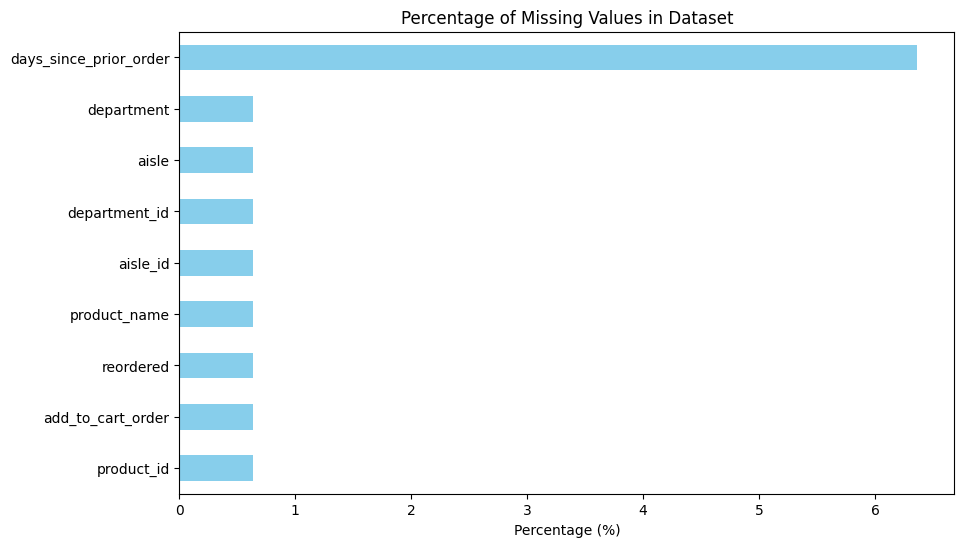

In [21]:
missing_percentage = missing_percentage[missing_percentage > 0]

if not missing_percentage.empty:
    missing_percentage.sort_values().plot(kind='barh', figsize=(10, 6), color='skyblue')
    plt.title('Percentage of Missing Values in Dataset')
    plt.xlabel('Percentage (%)')
    plt.show()
else:
  print("There are not missing values")

This script handles missing values in categorical and numeric columns. For categorical columns ('product_name', 'aisle', 'department'), it adds an 'Unknown' category if missing, then fills NaNs with 'Unknown'. For numeric columns ('product_id', 'aisle_id', 'department_id', 'add_to_cart_order', 'reordered'), it fills missing values with -1 and converts to int32 type.

In [22]:
for col in ['product_name', 'aisle', 'department']:
    if My_Data[col].dtype.name == 'category' and 'Unknown' not in My_Data[col].cat.categories:
        My_Data[col] = My_Data[col].cat.add_categories(['Unknown'])
    My_Data[col] = My_Data[col].fillna('Unknown')

for col in ['product_id', 'aisle_id', 'department_id', 'add_to_cart_order', 'reordered']:
    My_Data[col] = My_Data[col].fillna(-1).astype('int32')

In [23]:
My_Data['days_since_prior_order'] = My_Data['days_since_prior_order'].fillna(-1)

In [24]:
missing_data = My_Data.isnull().sum()
print(missing_data)

print("-------------------------------")
missing_percentage = (My_Data.isnull().sum() / len(My_Data)) * 100
print(missing_percentage)

order_id                  0
user_id                   0
eval_set                  0
order_number              0
order_dow                 0
order_hour_of_day         0
days_since_prior_order    0
product_id                0
add_to_cart_order         0
reordered                 0
product_name              0
aisle_id                  0
department_id             0
aisle                     0
department                0
dtype: int64
-------------------------------
order_id                  0.0
user_id                   0.0
eval_set                  0.0
order_number              0.0
order_dow                 0.0
order_hour_of_day         0.0
days_since_prior_order    0.0
product_id                0.0
add_to_cart_order         0.0
reordered                 0.0
product_name              0.0
aisle_id                  0.0
department_id             0.0
aisle                     0.0
department                0.0
dtype: float64


This script visualizes the distribution of orders across hours of the day. It counts orders per hour, ensures hours are sorted sequentially, and creates a bar plot showing total orders for each hour (0-23). The plot helps identify peak ordering times.

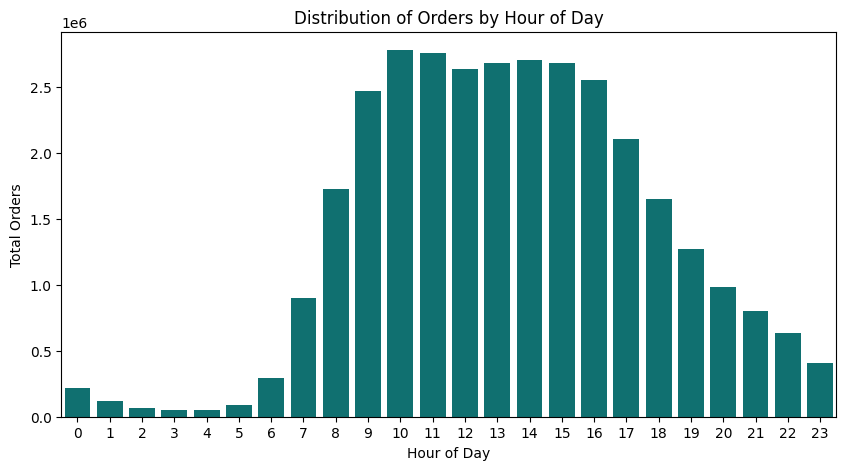

In [25]:
hourly_dist = My_Data['order_hour_of_day'].value_counts().sort_index()

plt.figure(figsize=(10, 5))
sns.barplot(x=hourly_dist.index, y=hourly_dist.values, color='teal')
plt.title('Distribution of Orders by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Total Orders')
plt.show()

This script visualizes order distribution across days of the week. It counts orders per day (0-6), sorts by day index, and creates a bar plot with custom labels (Saturday through Friday). The plot reveals which days have the highest order volumes.

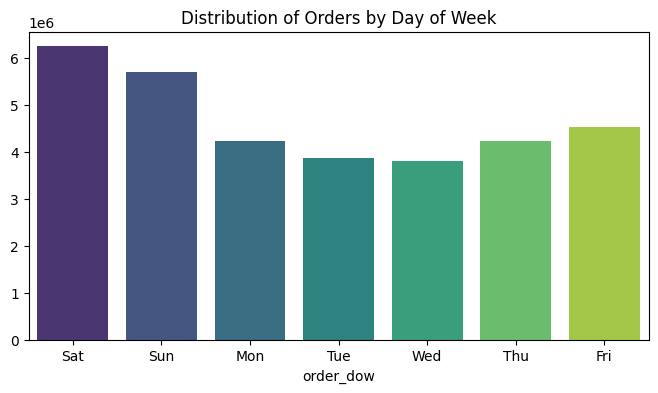

In [26]:
dow_dist = My_Data['order_dow'].value_counts().sort_index()

plt.figure(figsize=(8, 4))
sns.barplot(x=dow_dist.index, y=dow_dist.values, palette='viridis')
plt.title('Distribution of Orders by Day of Week')
plt.xticks(ticks=[0,1,2,3,4,5,6], labels=['Sat','Sun', 'Mon', 'Tue', 'Wed', 'Thu', 'Fri'])
plt.show()

This script creates a kernel density estimate (KDE) plot of 'days_since_prior_order' using a random sample of 2 million non-null values. The density plot shows the distribution of time gaps between consecutive orders for the same user.

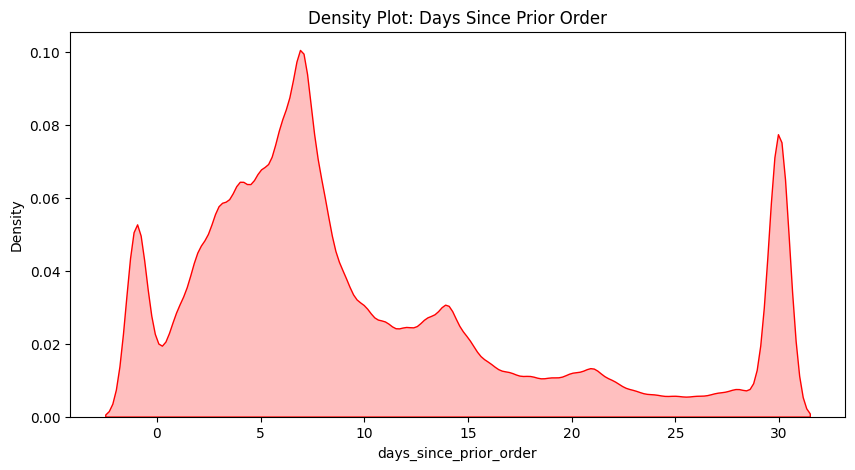

In [27]:
sample_data = My_Data['days_since_prior_order'].dropna().sample(2000000)

plt.figure(figsize=(10, 5))
sns.kdeplot(sample_data, fill=True, color="r")
plt.title('Density Plot: Days Since Prior Order')
plt.show()

This script visualizes the distribution of add-to-cart order positions. It counts how often each position (1st item added, 2nd item added, etc.) occurs across all orders, then plots the top 50 positions. This shows which cart positions are most common (typically early positions like 1, 2, 3 are most frequent).

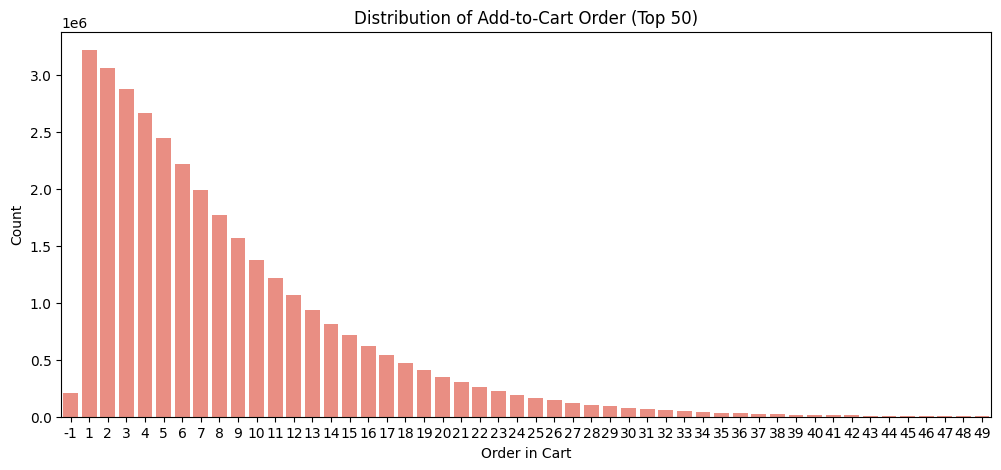

In [28]:
cart_dist = My_Data['add_to_cart_order'].value_counts().head(50)

plt.figure(figsize=(12, 5))
sns.barplot(x=cart_dist.index, y=cart_dist.values, color='salmon')
plt.title('Distribution of Add-to-Cart Order (Top 50)')
plt.xlabel('Order in Cart')
plt.ylabel('Count')
plt.show()

This script creates a histogram of the 'order_number' field, representing customer loyalty or tenure (1 = first order, higher numbers = repeat customers). The distribution shows how many users reach each order sequence number, typically revealing that most users have low order numbers (fewer repeat purchases).

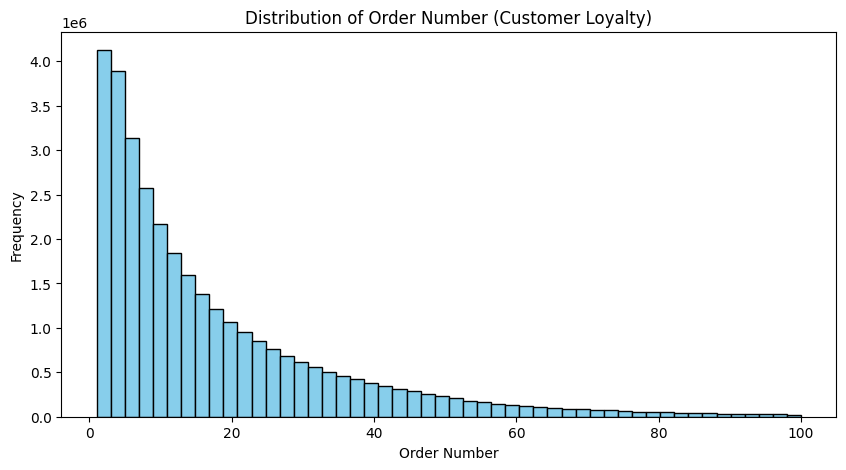

In [29]:
plt.figure(figsize=(10, 5))
plt.hist(My_Data['order_number'], bins=50, color='skyblue', edgecolor='black')
plt.title('Distribution of Order Number (Customer Loyalty)')
plt.xlabel('Order Number')
plt.ylabel('Frequency')
plt.show()

This script visualizes the frequency of items across all aisles. It counts occurrences per aisle, sorts from highest to lowest, and creates a horizontal bar plot. The large figure size (15x30) accommodates many aisle names, revealing which aisles are most frequently ordered.

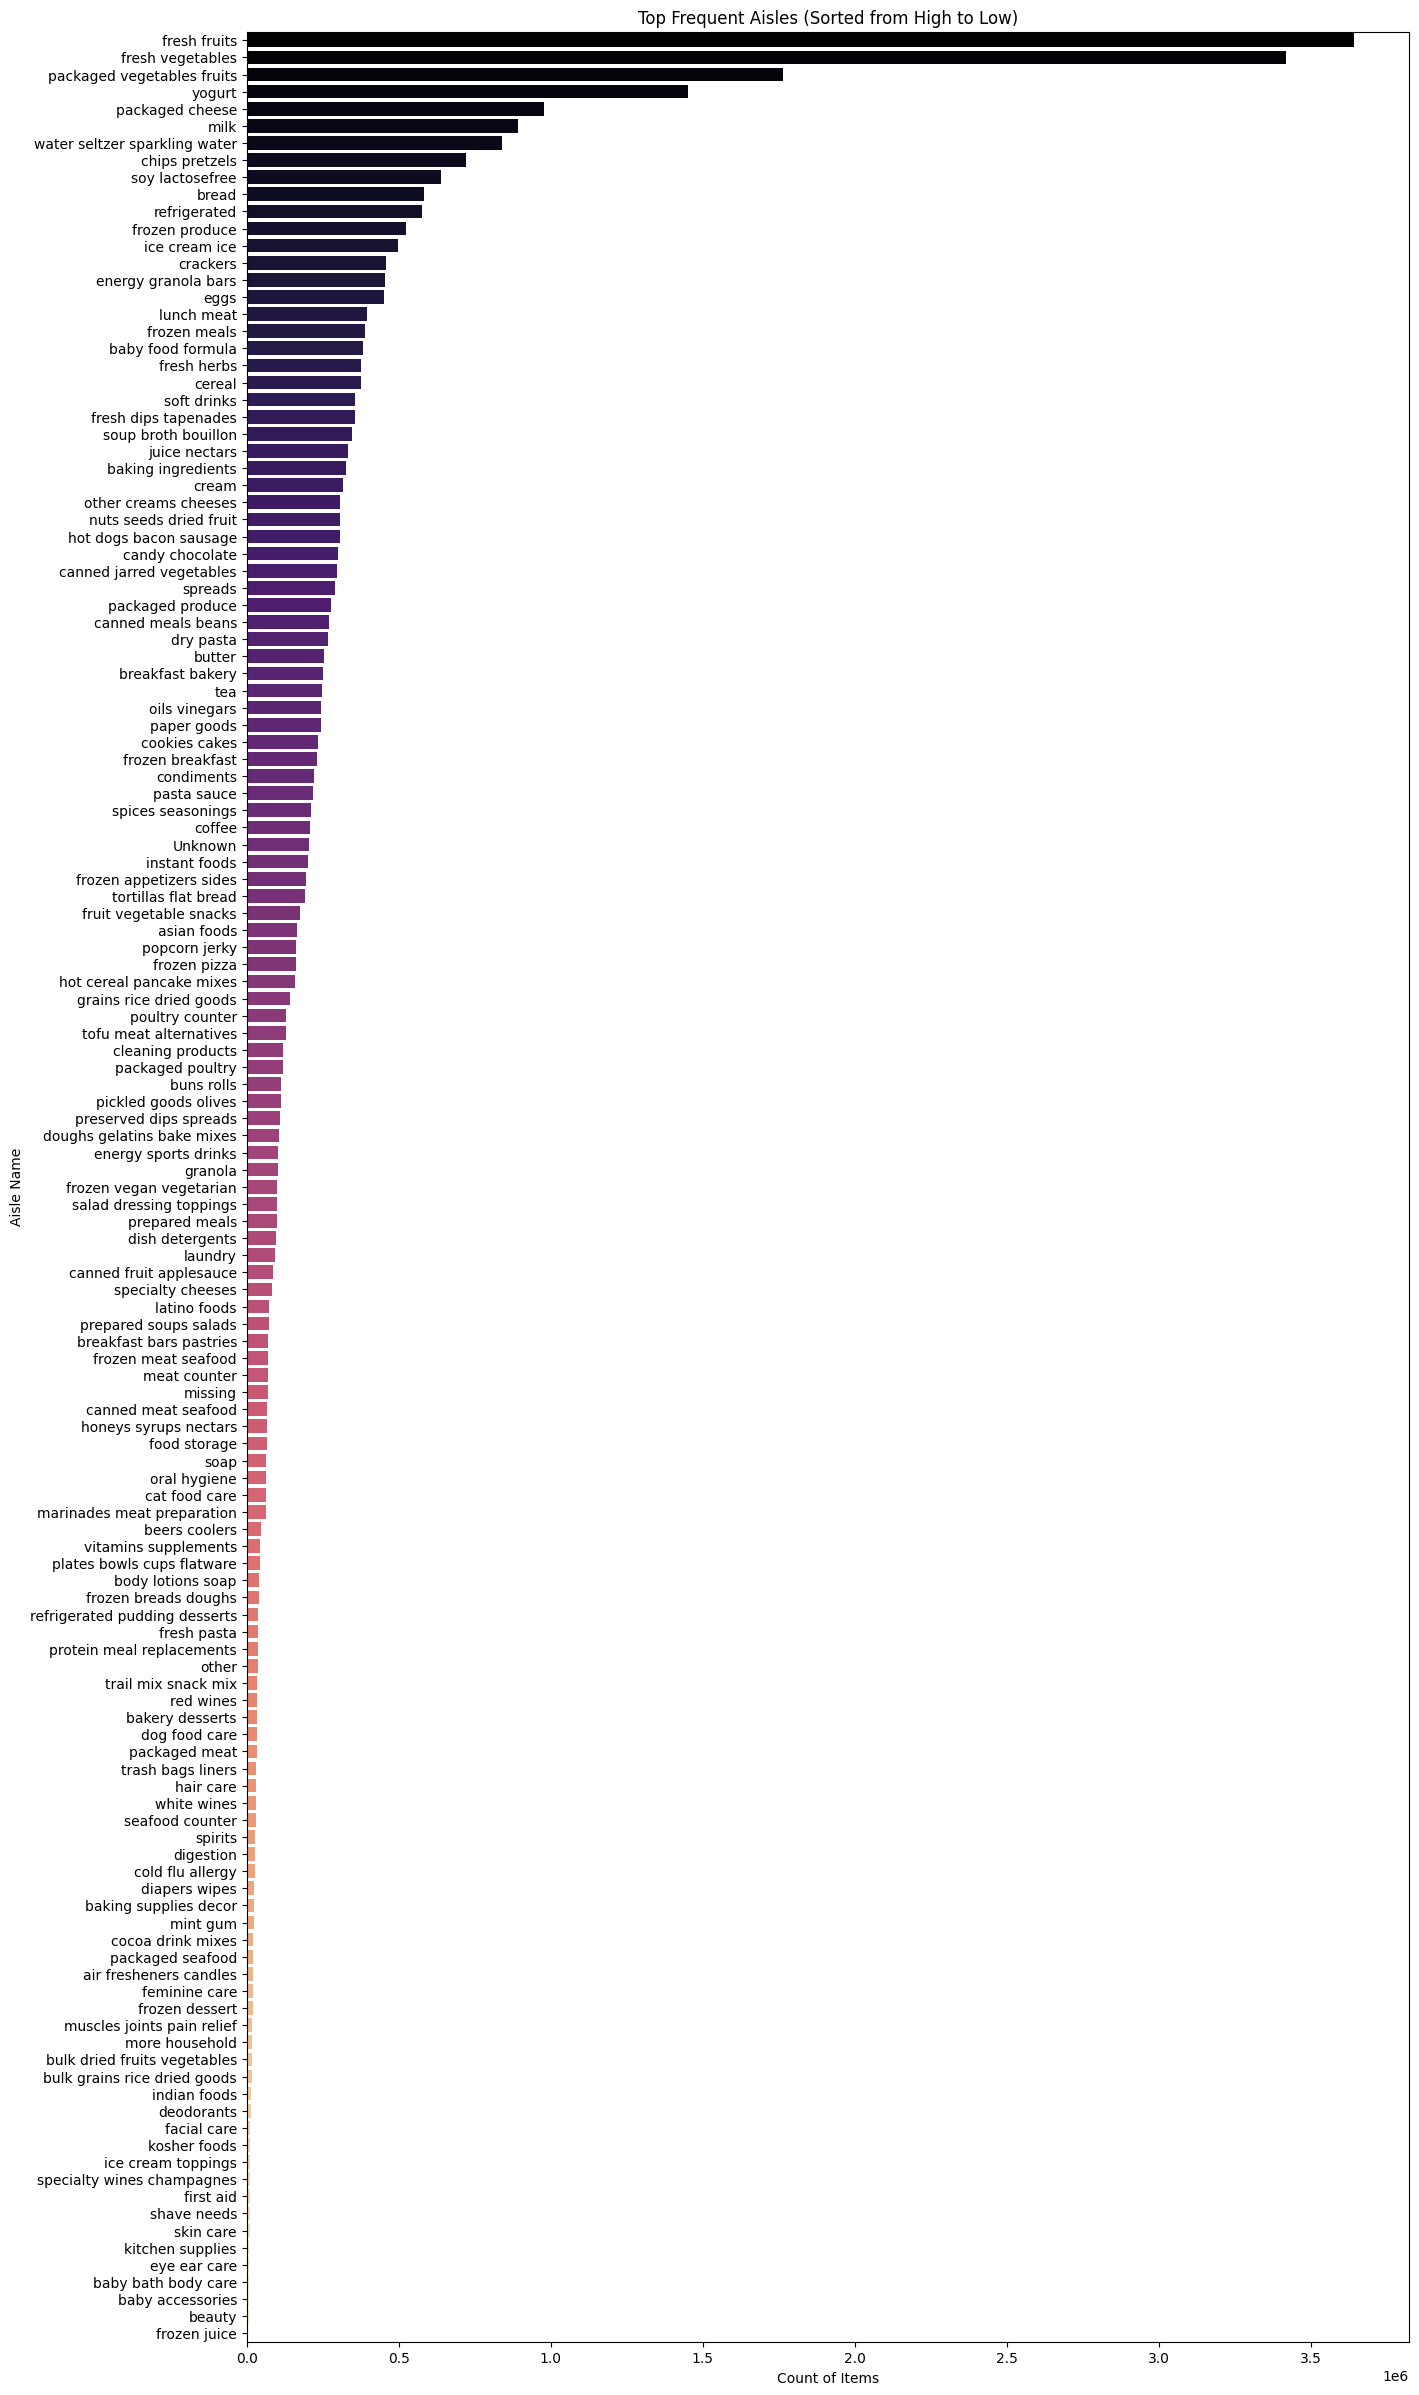

In [30]:
top_aisles = My_Data['aisle'].value_counts()

plt.figure(figsize=(15, 30))

sns.barplot(
    x=top_aisles.values,
    y=top_aisles.index,
    order=top_aisles.index,
    palette='magma'
)

plt.title('Top Frequent Aisles (Sorted from High to Low)')
plt.xlabel('Count of Items')
plt.ylabel('Aisle Name')
plt.show()

This script visualizes item frequency across departments. It counts occurrences per department, sorts them, and creates a horizontal bar plot showing which departments have the most ordered items (e.g., produce, dairy, beverages).

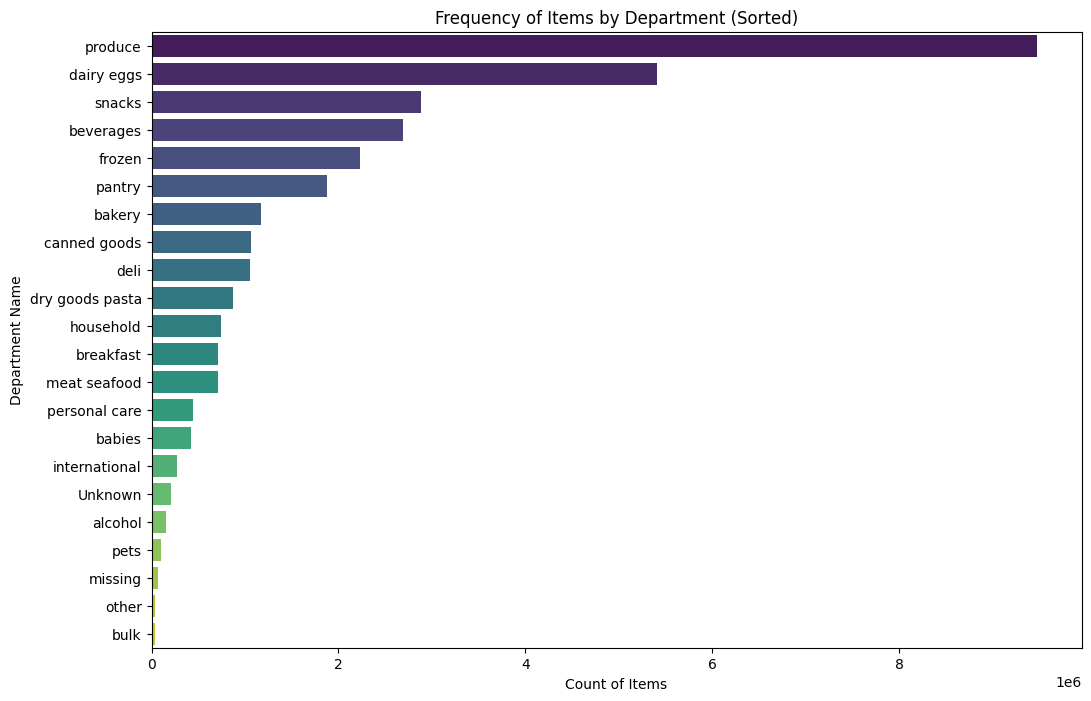

In [31]:
dept_counts = My_Data['department'].value_counts()

plt.figure(figsize=(12, 8))
sns.barplot(
    x=dept_counts.values,
    y=dept_counts.index,
    order=dept_counts.index,
    palette='viridis'
)

plt.title('Frequency of Items by Department (Sorted)')
plt.xlabel('Count of Items')
plt.ylabel('Department Name')
plt.show()

This script calculates and visualizes the cardinality (number of unique values) of categorical features. It focuses on 'aisle', 'department', 'product_name', and 'eval_set', sorts them, and displays a horizontal bar plot with a logarithmic x-axis to handle the wide range (product_name likely has thousands of unique values while eval_set has only a few). This helps assess feature suitability for encoding.

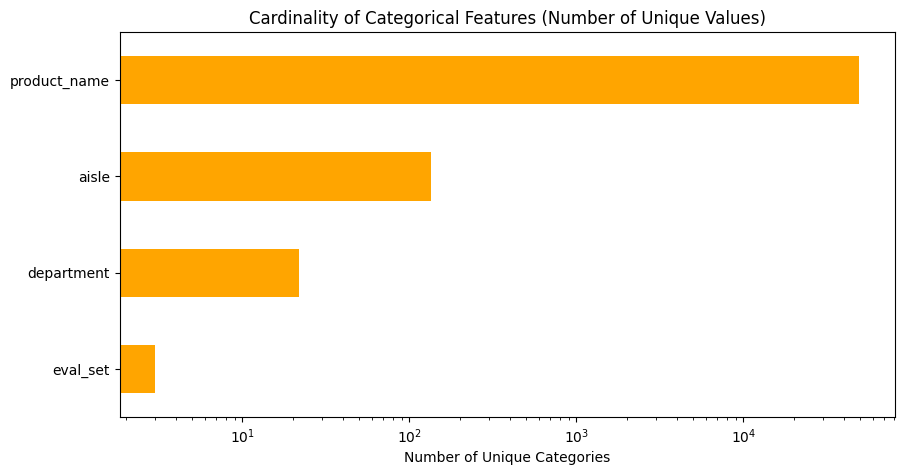

In [32]:
categorical_cols = ['aisle', 'department', 'product_name', 'eval_set']
cardinality = My_Data[categorical_cols].nunique().sort_values()

plt.figure(figsize=(10, 5))
cardinality.plot(kind='barh', color='orange')
plt.title('Cardinality of Categorical Features (Number of Unique Values)')
plt.xlabel('Number of Unique Categories')
plt.xscale('log')
plt.show()

This script analyzes weekly seasonality by counting unique orders per day of the week. It creates a line plot (with square markers) showing order volume trends across Sunday to Saturday, helping identify peak shopping days and weekly patterns in customer behavior.

In [34]:
# Full feature matrix and target (after all feature engineering)
X_full = My_Data.drop('reordered', axis=1)  # All features
y_full = My_Data['reordered']              # Target column (0/1)


X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X_full, y_full, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_full
)

print(f"Training set size: {X_train_full.shape[0]} samples")
print(f"Test set size: {X_test_full.shape[0]} samples")

Training set size: 26112558 samples
Test set size: 6528140 samples


This script computes and visualizes the correlation matrix for numeric features: order_number, order_dow, order_hour_of_day, days_since_prior_order, add_to_cart_order, and reordered. A heatmap with annotations (rounded to 2 decimals) shows pairwise correlations using a coolwarm colormap, helping identify linear relationships between features.

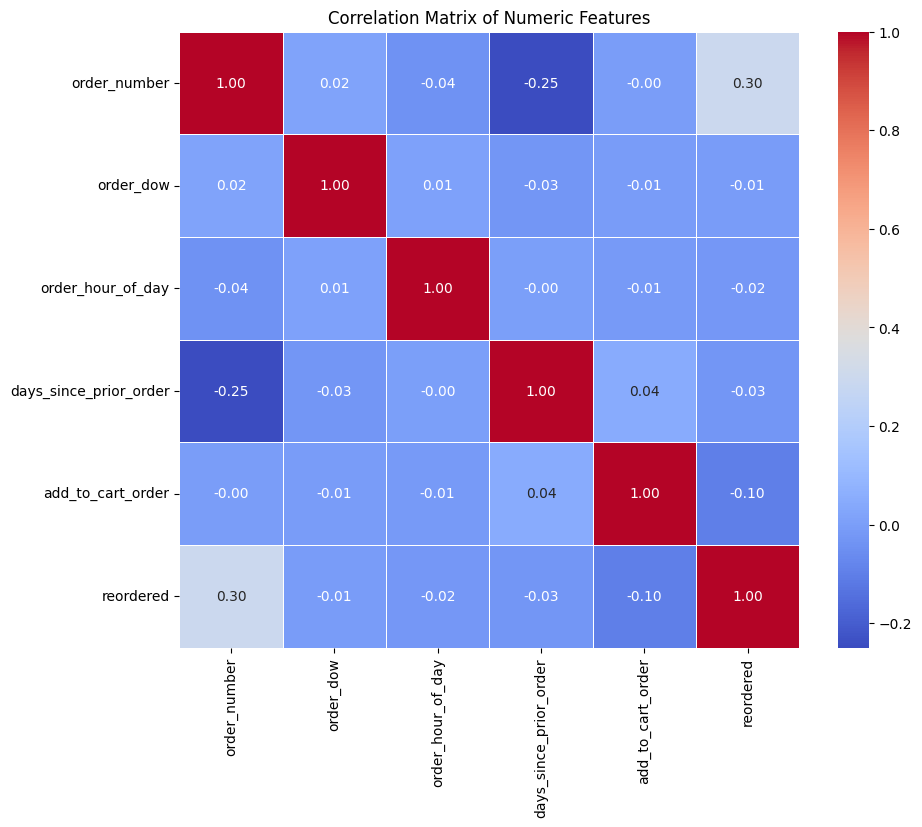

In [44]:
numeric_cols = ['order_number', 'order_dow', 'order_hour_of_day',
                'days_since_prior_order', 'add_to_cart_order', 'reordered']

corr_matrix = My_Data[numeric_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Numeric Features')
plt.show()

In [20]:
!pip install umap-learn --progress-bar on


[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
from sklearn.manifold import TSNE
from sklearn.metrics import (roc_auc_score, precision_score, recall_score, f1_score, 
                             confusion_matrix, precision_recall_curve, average_precision_score)
import lightgbm as lgb
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
mport os
import gc
import time
from sklearn.manifold import TSNE
from sklearn.metrics import (roc_auc_score, precision_score, recall_score, f1_score, 
                             confusion_matrix, precision_recall_curve, average_precision_score)
import lightgbm as lgb
import xgboost as xgb
import umap.umap_ as umap
from tqdm.notebook import tqdm

This script builds a complete recommendation feature pipeline for the Instacart dataset. It merges product, aisle, and department data, then creates three levels of features: user-level (order totals, basket size, reorder rate, order gaps), product-level (purchase count, reorder rate, unique users), and user-product-level (interaction frequency, reorder rate, recency, product share). It constructs a training dataset by pairing positive labels (products purchased in train orders) with negative samples (prior products not purchased in train orders), merges all features, handles missing values, and splits into train/validation sets (70/30 with stratification).

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

aisle_data = pd.read_csv('aisles.csv')
dept_data = pd.read_csv('departments.csv')
product_data = pd.read_csv('products.csv')
order_data = pd.read_csv('orders.csv')
prior_order_items = pd.read_csv('order_products__prior.csv')
train_order_items = pd.read_csv('order_products__train.csv')

product_data = product_data.merge(aisle_data, left_on='aisle_id', right_on='aisle_id', how='left')
product_data = product_data.merge(dept_data, left_on='department_id', right_on='department_id', how='left')

prior_orders_only = order_data[order_data['eval_set'] == 'prior'].copy()
prior_full = prior_orders_only.merge(prior_order_items, on='order_id', how='inner')

user_group = prior_full.groupby('user_id')

user_profile = pd.DataFrame({
    'user_id': user_group['order_id'].nunique().index,
    'order_total': user_group['order_id'].nunique().values,
    'item_total': user_group['product_id'].count().values
})

basket_size = prior_full.groupby(['user_id', 'order_id']).size().groupby('user_id').mean()
user_profile['avg_basket'] = user_profile['user_id'].map(basket_size).fillna(0)

user_profile['reorder_mean'] = user_group['reordered'].mean().values

user_profile['days_gap_mean'] = user_group['days_since_prior_order'].mean().values
user_profile['days_gap_std'] = user_group['days_since_prior_order'].std().values
user_profile['days_gap_std'] = user_profile['days_gap_std'].fillna(0)

last_order_info = prior_orders_only.groupby('user_id')['days_since_prior_order'].max().reset_index()
last_order_info.columns = ['user_id', 'last_gap_days']
user_profile = user_profile.merge(last_order_info, on='user_id', how='left')
user_profile['last_gap_days'] = user_profile['last_gap_days'].fillna(0)

product_group = prior_full.groupby('product_id')

product_profile = pd.DataFrame({
    'product_id': product_group['order_id'].count().index,
    'buy_count': product_group['order_id'].count().values,
    'reorder_rate': product_group['reordered'].mean().values,
    'user_unique': product_group['user_id'].nunique().values,
    'cart_pos_mean': product_group['add_to_cart_order'].mean().values
})

product_last = prior_full.groupby('product_id')['days_since_prior_order'].max().reset_index()
product_last.columns = ['product_id', 'last_buy_days']
product_profile = product_profile.merge(product_last, on='product_id', how='left')
product_profile['last_buy_days'] = product_profile['last_buy_days'].fillna(0)

product_profile = product_profile.merge(product_data[['product_id', 'aisle_id', 'department_id']], on='product_id', how='left')

user_product_group = prior_full.groupby(['user_id', 'product_id'])

user_product_profile = pd.DataFrame({
    'user_id': [x[0] for x in user_product_group['order_id'].count().index],
    'product_id': [x[1] for x in user_product_group['order_id'].count().index],
    'buy_frequency': user_product_group['order_id'].count().values,
    'user_reorder_rate': user_product_group['reordered'].mean().values,
    'last_buy_gap': user_product_group['days_since_prior_order'].max().values,
    'cart_position_avg': user_product_group['add_to_cart_order'].mean().values
})

user_product_profile['last_buy_gap'] = user_product_profile['last_buy_gap'].fillna(0)

user_total_items = prior_full.groupby('user_id').size().reset_index(name='total_user_items')
user_product_profile = user_product_profile.merge(user_total_items, on='user_id', how='left')
user_product_profile['product_share'] = user_product_profile['buy_frequency'] / user_product_profile['total_user_items']

train_orders_only = order_data[order_data['eval_set'] == 'train'].copy()
train_full = train_orders_only.merge(train_order_items, on='order_id', how='inner')

user_prior_list = prior_full.groupby('user_id')['product_id'].unique().reset_index()
user_prior_list.columns = ['user_id', 'prior_products']

user_train_list = train_full.groupby('user_id')['product_id'].apply(list).reset_index()
user_train_list.columns = ['user_id', 'train_products']

positive_samples = train_full[['user_id', 'product_id']].copy()
positive_samples['label'] = 1

candidate_users = user_prior_list.merge(user_train_list, on='user_id', how='inner')

negative_samples_list = []
for idx, row_data in candidate_users.iterrows():
    current_user = row_data['user_id']
    prior_set = set(row_data['prior_products'])
    train_set = set(row_data['train_products'])
    
    negative_candidates = list(prior_set - train_set)
    if len(negative_candidates) > 10:
        negative_candidates = np.random.choice(negative_candidates, size=10, replace=False)
    
    for prod_id in negative_candidates:
        negative_samples_list.append({'user_id': current_user, 'product_id': prod_id, 'label': 0})

negative_samples = pd.DataFrame(negative_samples_list)

final_dataset = pd.concat([positive_samples, negative_samples], axis=0, ignore_index=True)
final_dataset = final_dataset.sample(frac=1, random_state=42).reset_index(drop=True)

final_dataset = final_dataset.merge(user_profile, on='user_id', how='left')
final_dataset = final_dataset.merge(product_profile, on='product_id', how='left')
final_dataset = final_dataset.merge(user_product_profile, on=['user_id', 'product_id'], how='left')

missing_fill = {
    'buy_frequency': 0,
    'user_reorder_rate': 0,
    'last_buy_gap': -1,
    'cart_position_avg': -1,
    'product_share': 0
}
final_dataset.fillna(missing_fill, inplace=True)

feature_columns = final_dataset.drop(['user_id', 'product_id', 'label'], axis=1)
target_column = final_dataset['label']

X_train_set, X_validation_set, y_train_set, y_validation_set = train_test_split(
    feature_columns, target_column, test_size=0.3, random_state=42, stratify=target_column
)

print(f"Training set size: {X_train_set.shape[0]}")
print(f"Validation set size: {X_validation_set.shape[0]}")

Training set size: 1850787
Validation set size: 793195


This script trains a LightGBM classifier for product recommendation (predicting whether a user will reorder a product). It sets up a binary classification model, performs grid search with 3-fold stratified cross-validation over hyperparameters (n_estimators, max_depth, learning_rate, num_leaves, subsample) optimizing for ROC-AUC. After finding the best model, it evaluates on the validation set using AUC, precision, recall, and F1-score, using a classification threshold of 0.48.

In [7]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score

lgb_setup = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'verbose': -1,
    'random_state': 42,
    'n_jobs': -1
}

lgb_estimator = LGBMClassifier(**lgb_setup)

param_grid_search = {
    'n_estimators': [120, 180],
    'max_depth': [5,6,8],
    'learning_rate': [0.08, 0.11],
    'num_leaves': [55, 75],
    'subsample': [0.75,0.98]
}

kfold_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=99)

grid_search_obj = GridSearchCV(
    lgb_estimator, 
    param_grid_search, 
    cv=kfold_cv, 
    scoring='roc_auc', 
    n_jobs=3, 
    verbose=1
)
grid_search_obj.fit(X_train_set, y_train_set)

print("\n" + "="*55)
print(">>> GRID SEARCH COMPLETED <<<")
print("="*55)
print(f"[INFO] Best parameters found: {grid_search_obj.best_params_}")
print(f"[INFO] Best CV AUC score: {grid_search_obj.best_score_:.6f}")
print("="*55)

best_lgb_model = grid_search_obj.best_estimator_

val_pred_proba = best_lgb_model.predict_proba(X_validation_set)[:, 1]
val_pred_class = (val_pred_proba >= 0.48).astype(int)

val_auc = roc_auc_score(y_validation_set, val_pred_proba)
val_precision = precision_score(y_validation_set, val_pred_class)
val_recall = recall_score(y_validation_set, val_pred_class)
val_f1 = f1_score(y_validation_set, val_pred_class)

print("\n" + "="*55)
print(">>> VALIDATION RESULTS <<<")
print("="*55)
print(f"[AUC] ......... {val_auc:.5f}")
print(f"[Precision] ... {val_precision:.5f}")
print(f"[Recall] ...... {val_recall:.5f}")
print(f"[F1-Score] .... {val_f1:.5f}")
print("="*55)

print("\n" + "-"*55)
print(f"FINAL REPORT -> AUC={val_auc:.4f} | F1={val_f1:.4f} | PRE={val_precision:.4f} | REC={val_recall:.4f}")
print("-"*55)

Fitting 3 folds for each of 48 candidates, totalling 144 fits

>>> GRID SEARCH COMPLETED <<<
[INFO] Best parameters found: {'learning_rate': 0.11, 'max_depth': 8, 'n_estimators': 180, 'num_leaves': 75, 'subsample': 0.75}
[INFO] Best CV AUC score: 0.878511

>>> VALIDATION RESULTS <<<
[AUC] ......... 0.87878
[Precision] ... 0.83100
[Recall] ...... 0.76169
[F1-Score] .... 0.79483

-------------------------------------------------------
FINAL REPORT -> AUC=0.8788 | F1=0.7948 | PRE=0.8310 | REC=0.7617
-------------------------------------------------------


This script performs hyperparameter tuning for a LightGBM binary classifier using grid search with 3-fold stratified cross-validation, optimizing for ROC-AUC. It defines a parameter grid over n_estimators, max_depth, learning_rate, num_leaves, and subsample, then evaluates the best model on a validation set using AUC, precision, recall, and F1-score with a classification threshold of 0.52.

In [9]:
lightgbm_config = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'verbose': -1,
    'random_state': 42,
    'n_jobs': -1
}

lgb_classifier = lgb.LGBMClassifier(**lightgbm_config)

hyperparams_search ={
    'n_estimators': [120, 180],
    'max_depth': [5,6,8],
    'learning_rate': [0.08, 0.11],
    'num_leaves': [55, 75],
    'subsample': [0.75,0.98]
}

cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=77)
grid_search_cv = GridSearchCV(lgb_classifier, hyperparams_search, cv=cv_strategy, scoring='roc_auc', n_jobs=2, verbose=2)
grid_search_cv.fit(X_train_set, y_train_set)

print("\n" + "="*50)
print(">>> LIGHTGBM TUNING RESULTS <<<")
print("="*50)
print(f"Best params: {grid_search_cv.best_params_}")
print(f"Best CV AUC: {grid_search_cv.best_score_:.5f}")
print("="*50)

best_lgb = grid_search_cv.best_estimator_
val_proba_lgb = best_lgb.predict_proba(X_validation_set)[:, 1]
val_preds_lgb = (val_proba_lgb >= 0.52).astype(int)

auc_val = roc_auc_score(y_validation_set, val_proba_lgb)
precision_val_lgb = precision_score(y_validation_set, val_preds_lgb)
recall_val_lgb = recall_score(y_validation_set, val_preds_lgb)
f1_val_lgb = f1_score(y_validation_set, val_preds_lgb)

print("\n" + "="*50)
print(">>> LIGHTGBM VALIDATION METRICS <<<")
print("="*50)
print(f"[AUC] ......... {auc_val:.5f}")
print(f"[Precision] ... {precision_val_lgb:.5f}")
print(f"[Recall] ...... {recall_val_lgb:.5f}")
print(f"[F1-Score] .... {f1_val_lgb:.5f}")
print("="*50)

print("\n" + "-"*50)
print(f"LGBM SUMMARY | AUC:{auc_val:.4f} | F1:{f1_val_lgb:.4f} | P:{precision_val_lgb:.4f} | R:{recall_val_lgb:.4f}")
print("-"*50)

Fitting 3 folds for each of 48 candidates, totalling 144 fits

>>> LIGHTGBM TUNING RESULTS <<<
Best params: {'learning_rate': 0.11, 'max_depth': 8, 'n_estimators': 180, 'num_leaves': 75, 'subsample': 0.75}
Best CV AUC: 0.87852

>>> LIGHTGBM VALIDATION METRICS <<<
[AUC] ......... 0.87878
[Precision] ... 0.85221
[Recall] ...... 0.73422
[F1-Score] .... 0.78882

--------------------------------------------------
LGBM SUMMARY | AUC:0.8788 | F1:0.7888 | P:0.8522 | R:0.7342
--------------------------------------------------


This script trains and tunes an XGBoost classifier for the same product reorder prediction task. It sets up a base XGBoost model with histogram tree method, gamma, and min_child_weight regularization. Grid search explores n_estimators, max_depth, learning_rate, subsample, and colsample_bytree using 3-fold stratified CV optimizing for ROC-AUC. After tuning, it uses a dynamic threshold (bounded between 0.35 and 0.65) based on the positive class ratio in training, then evaluates on validation set with AUC, precision, recall, F1, and confusion matrix.

In [21]:


import xgboost as xgb
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, confusion_matrix

RANDOM_CORE = 777  

xgb_base_config = {
    'objective': 'binary:logistic',
    'eval_metric': 'logloss', 
    'random_state': RANDOM_CORE,
    'verbosity': 0,
    'n_jobs': -1,
    'tree_method': 'hist',  
    'gamma': 0.1, 
    'min_child_weight': 3  
}

xgb_estimator = xgb.XGBClassifier(**xgb_base_config)


hyperparams_xgb = {
    'n_estimators': [120, 180],  
    'max_depth': [6,8],  
    'learning_rate': [0.08, 0.11], 
    'subsample': [0.75,0.98], 
    'colsample_bytree': [ 0.85, 0.95],
}

stratified_cv_xgb = StratifiedKFold(n_splits=3, shuffle=True, random_state=555)

print("\n" + "-"*60)
print(">> XGBOOST  <<")
print("-"*60)

xgb_grid_search = GridSearchCV(
    xgb_estimator, 
    hyperparams_xgb, 
    cv=stratified_cv_xgb, 
    scoring='roc_auc', 
    n_jobs=2, 
    verbose=2
)

xgb_grid_search.fit(X_train_set, y_train_set)

print("\n" + "-"*60)
print(">> XGBOOST TUNING COMPLETED  <<")
print("-"*60)
print(f"[] Optimal parameters found: {xgb_grid_search.best_params_}")
print(f"[] Best cross-validation AUC: {xgb_grid_search.best_score_:.6f}")
print("-"*60)


xgb_optimal_model = xgb_grid_search.best_estimator_


xgb_val_probabilities = xgb_optimal_model.predict_proba(X_validation_set)[:, 1]

positive_ratio = y_train_set.mean()
dynamic_threshold = max(0.35, min(0.65, positive_ratio))  

xgb_val_predictions = (xgb_val_probabilities >= dynamic_threshold).astype(int)


xgb_auc_value = roc_auc_score(y_validation_set, xgb_val_probabilities)
xgb_precision_value = precision_score(y_validation_set, xgb_val_predictions)
xgb_recall_value = recall_score(y_validation_set, xgb_val_predictions)
xgb_f1_value = f1_score(y_validation_set, xgb_val_predictions)
xgb_confusion_matrix = confusion_matrix(y_validation_set, xgb_val_predictions)

print("\n" + "-"*60)
print(">> XGBOOST VALIDATION PERFORMANCE REPORT <<")
print("-"*60)
print(f"AUC Score: ........ {xgb_auc_value:.5f}")
print(f" Precision: ........ {xgb_precision_value:.5f}")
print(f" Recall: ........... {xgb_recall_value:.5f}")
print(f" F1-Score: ......... {xgb_f1_value:.5f}")
print(f" Dynamic Threshold: . {dynamic_threshold:.3f}")


------------------------------------------------------------
>> XGBOOST  <<
------------------------------------------------------------
Fitting 3 folds for each of 32 candidates, totalling 96 fits

------------------------------------------------------------
>> XGBOOST TUNING COMPLETED  <<
------------------------------------------------------------
[] Optimal parameters found: {'colsample_bytree': 0.85, 'learning_rate': 0.11, 'max_depth': 8, 'n_estimators': 180, 'subsample': 0.98}
[] Best cross-validation AUC: 0.878676
------------------------------------------------------------

------------------------------------------------------------
>> XGBOOST VALIDATION PERFORMANCE REPORT <<
------------------------------------------------------------
AUC Score: ........ 0.87905
 Precision: ........ 0.85440
 Recall: ........... 0.73201
 F1-Score: ......... 0.78848
 Dynamic Threshold: . 0.524


This script provides a comprehensive model comparison between LightGBM and XGBoost using confusion matrices, ROC curves, and extended metrics. It visualizes both raw and normalized confusion matrices, plots ROC curves with AUC values, and generates a detailed comparison report including specificity (True Negative Rate) and NPV (Negative Predictive Value). The report also highlights differences in classification thresholds (fixed 0.52 for LightGBM vs dynamic threshold for XGBoost based on training set positive ratio).

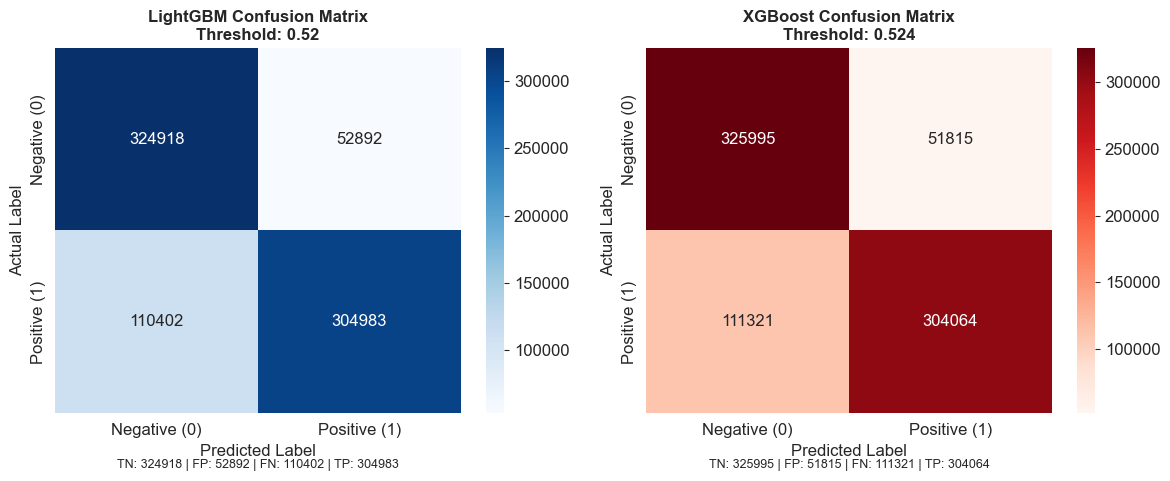

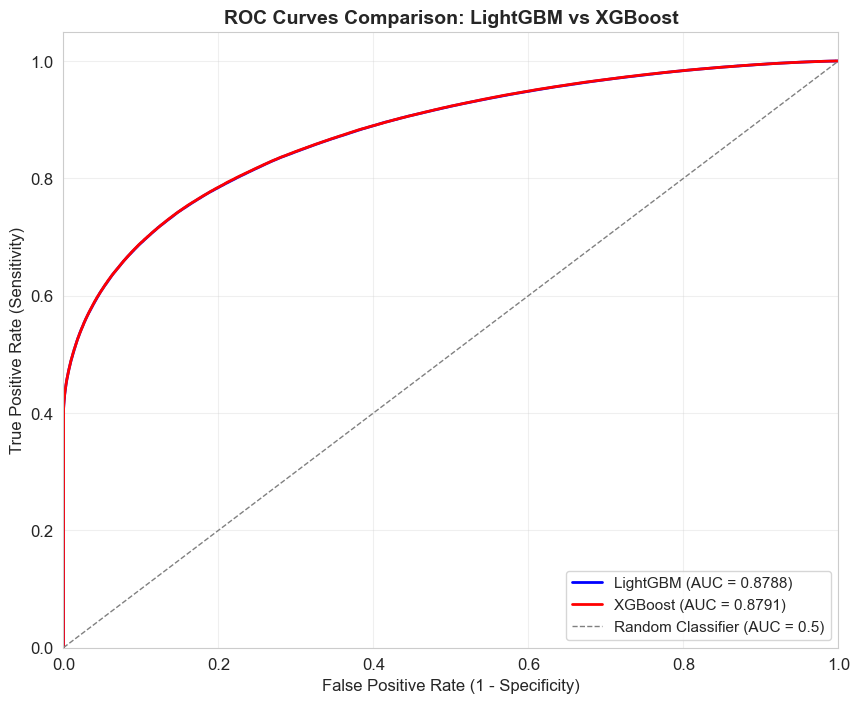


>>> COMPREHENSIVE MODEL COMPARISON REPORT <<<

----------------------------------------------------------------------
CONFUSION MATRIX DETAILS:
----------------------------------------------------------------------
Metric                     LightGBM             XGBoost       
----------------------------------------------------------------------
True Negatives (TN)         324918               325995       
False Positives (FP)        52892                51815        
False Negatives (FN)        110402               111321       
True Positives (TP)         304983               304064       
----------------------------------------------------------------------

----------------------------------------------------------------------
PERFORMANCE METRICS:
----------------------------------------------------------------------
Metric                     LightGBM             XGBoost       
----------------------------------------------------------------------
AUC                  0.87878 

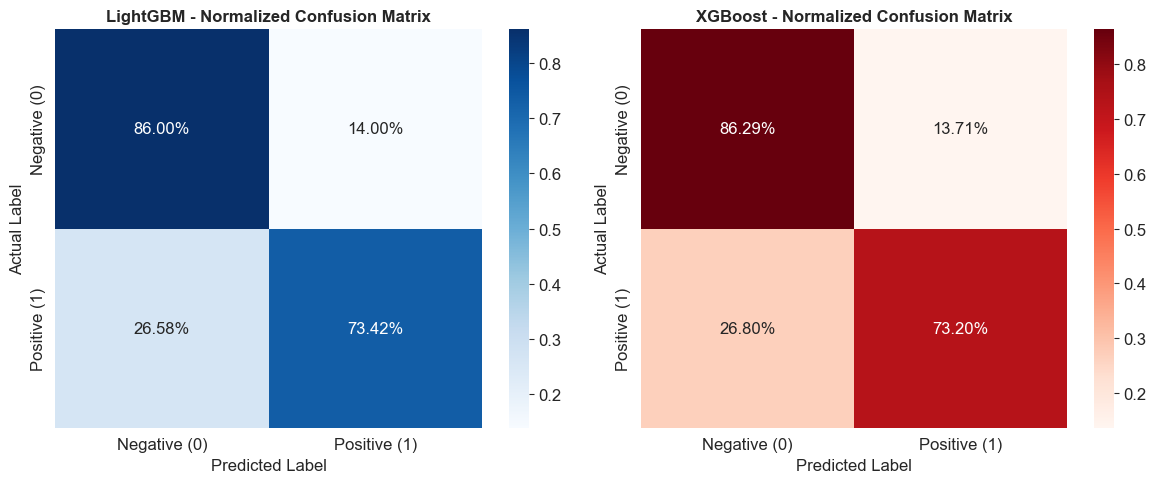


----------------------------------------------------------------------
EXTENDED METRICS (Specificity & NPV):
----------------------------------------------------------------------
Metric                     LightGBM             XGBoost       
----------------------------------------------------------------------
Specificity (TNR)    0.86000               0.86285
NPV                  0.74639               0.74544


In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
import numpy as np


cm_lgb = confusion_matrix(y_validation_set, val_preds_lgb)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.heatmap(cm_lgb, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Negative (0)', 'Positive (1)'],
            yticklabels=['Negative (0)', 'Positive (1)'])
plt.title(f'LightGBM Confusion Matrix\nThreshold: 0.52', fontsize=12, fontweight='bold')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')


tn, fp, fn, tp = cm_lgb.ravel()
plt.text(0.5, -0.15, f'TN: {tn} | FP: {fp} | FN: {fn} | TP: {tp}', 
         ha='center', transform=plt.gca().transAxes, fontsize=9)


cm_xgb = confusion_matrix(y_validation_set, xgb_val_predictions)

plt.subplot(1, 2, 2)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Negative (0)', 'Positive (1)'],
            yticklabels=['Negative (0)', 'Positive (1)'])
plt.title(f'XGBoost Confusion Matrix\nThreshold: {dynamic_threshold:.3f}', 
          fontsize=12, fontweight='bold')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')

tn, fp, fn, tp = cm_xgb.ravel()
plt.text(0.5, -0.15, f'TN: {tn} | FP: {fp} | FN: {fn} | TP: {tp}', 
         ha='center', transform=plt.gca().transAxes, fontsize=9)

plt.tight_layout()
plt.show()


fpr_lgb, tpr_lgb, thresholds_lgb = roc_curve(y_validation_set, val_proba_lgb)
roc_auc_lgb = auc(fpr_lgb, tpr_lgb)

fpr_xgb, tpr_xgb, thresholds_xgb = roc_curve(y_validation_set, xgb_val_probabilities)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)

plt.figure(figsize=(10, 8))
plt.plot(fpr_lgb, tpr_lgb, color='blue', lw=2, 
         label=f'LightGBM (AUC = {roc_auc_lgb:.4f})')
plt.plot(fpr_xgb, tpr_xgb, color='red', lw=2, 
         label=f'XGBoost (AUC = {roc_auc_xgb:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random Classifier (AUC = 0.5)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
plt.title('ROC Curves Comparison: LightGBM vs XGBoost', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.show()


print("\n" + "="*70)
print(">>> COMPREHENSIVE MODEL COMPARISON REPORT <<<")
print("="*70)

print("\n" + "-"*70)
print("CONFUSION MATRIX DETAILS:")
print("-"*70)
print(f"{'Metric':<20} {'LightGBM':^20} {'XGBoost':^20}")
print("-"*70)
print(f"{'True Negatives (TN)':<20} {cm_lgb[0,0]:^20} {cm_xgb[0,0]:^20}")
print(f"{'False Positives (FP)':<20} {cm_lgb[0,1]:^20} {cm_xgb[0,1]:^20}")
print(f"{'False Negatives (FN)':<20} {cm_lgb[1,0]:^20} {cm_xgb[1,0]:^20}")
print(f"{'True Positives (TP)':<20} {cm_lgb[1,1]:^20} {cm_xgb[1,1]:^20}")
print("-"*70)

print("\n" + "-"*70)
print("PERFORMANCE METRICS:")
print("-"*70)
print(f"{'Metric':<20} {'LightGBM':^20} {'XGBoost':^20}")
print("-"*70)
print(f"{'AUC':<20} {auc_val:.5f}{'':<14} {xgb_auc_value:.5f}")
print(f"{'Precision':<20} {precision_val_lgb:.5f}{'':<14} {xgb_precision_value:.5f}")
print(f"{'Recall':<20} {recall_val_lgb:.5f}{'':<14} {xgb_recall_value:.5f}")
print(f"{'F1-Score':<20} {f1_val_lgb:.5f}{'':<14} {xgb_f1_value:.5f}")
print("-"*70)

print("\n" + "-"*70)
print("ADDITIONAL INFORMATION:")
print("-"*70)
print(f"LightGBM Classification Threshold: 0.52 (fixed)")
print(f"XGBoost Classification Threshold: {dynamic_threshold:.3f} (dynamic based on positive ratio)")
print(f"XGBoost Dynamic Threshold Formula: max(0.35, min(0.65, positive_ratio))")
print(f"Training Set Positive Ratio: {y_train_set.mean():.4f}")
print("-"*70)


fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_lgb_norm = cm_lgb.astype('float') / cm_lgb.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_lgb_norm, annot=True, fmt='.2%', cmap='Blues', 
            xticklabels=['Negative (0)', 'Positive (1)'],
            yticklabels=['Negative (0)', 'Positive (1)'], ax=axes[0])
axes[0].set_title('LightGBM - Normalized Confusion Matrix', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Actual Label')
axes[0].set_xlabel('Predicted Label')

cm_xgb_norm = cm_xgb.astype('float') / cm_xgb.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_xgb_norm, annot=True, fmt='.2%', cmap='Reds',
            xticklabels=['Negative (0)', 'Positive (1)'],
            yticklabels=['Negative (0)', 'Positive (1)'], ax=axes[1])
axes[1].set_title('XGBoost - Normalized Confusion Matrix', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Actual Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()


specificity_lgb = cm_lgb[0,0] / (cm_lgb[0,0] + cm_lgb[0,1])
specificity_xgb = cm_xgb[0,0] / (cm_xgb[0,0] + cm_xgb[0,1])

npv_lgb = cm_lgb[0,0] / (cm_lgb[0,0] + cm_lgb[1,0])
npv_xgb = cm_xgb[0,0] / (cm_xgb[0,0] + cm_xgb[1,0])

print("\n" + "-"*70)
print("EXTENDED METRICS (Specificity & NPV):")
print("-"*70)
print(f"{'Metric':<20} {'LightGBM':^20} {'XGBoost':^20}")
print("-"*70)
print(f"{'Specificity (TNR)':<20} {specificity_lgb:.5f}{'':<14} {specificity_xgb:.5f}")
print(f"{'NPV':<20} {npv_lgb:.5f}{'':<14} {npv_xgb:.5f}")
print("="*70)

This script evaluates ranking performance of LightGBM and XGBoost for recommendation tasks. It generates prediction scores for validation users, then computes ranking metrics at K=5 and K=10 including Precision@K, Recall@K, Hit Rate, MAP (Mean Average Precision), NDCG (Normalized Discounted Cumulative Gain), and MRR (Mean Reciprocal Rank). The evaluation is per-user (ranking products by predicted reorder probability for each user). A comparison table at K=10 shows the difference between XGBoost and LightGBM performance.

In [24]:
import numpy as np
import pandas as pd
from collections import defaultdict

lgb_ranking_scores = best_lgb_model.predict_proba(X_validation_set)[:, 1]
xgb_ranking_scores = xgb_optimal_model.predict_proba(X_validation_set)[:, 1]

ranking_eval_data = X_validation_set.copy()
ranking_eval_data['user_id'] = final_dataset.loc[X_validation_set.index, 'user_id'].values
ranking_eval_data['product_id'] = final_dataset.loc[X_validation_set.index, 'product_id'].values
ranking_eval_data['ground_truth'] = y_validation_set.values
ranking_eval_data['lgb_score'] = lgb_ranking_scores
ranking_eval_data['xgb_score'] = xgb_ranking_scores

ranking_eval_data = ranking_eval_data.drop_duplicates(subset=['user_id', 'product_id'])

def evaluate_ranking_performance(eval_df, score_column, k_values=[5, 10]):
    ranking_results = {k: defaultdict(list) for k in k_values}
    user_partitions = eval_df.groupby('user_id')
    
    for current_user, user_history in user_partitions:
        sorted_history = user_history.sort_values(score_column, ascending=False)
        total_positive_items = user_history['ground_truth'].sum()
        
        for k in k_values:
            top_k_items = sorted_history.head(k)
            relevant_in_topk = top_k_items['ground_truth'].sum()
            
            precision_val = relevant_in_topk / k
            ranking_results[k]['precision'].append(precision_val)
            
            recall_val = relevant_in_topk / total_positive_items if total_positive_items > 0 else 0
            ranking_results[k]['recall'].append(recall_val)
            
            hit_rate_val = 1 if relevant_in_topk > 0 else 0
            ranking_results[k]['hit_rate'].append(hit_rate_val)
            
            cumulative_hits = 0
            precisions_at_positions = []
            for pos, (_, row) in enumerate(top_k_items.iterrows(), 1):
                if row['ground_truth'] == 1:
                    cumulative_hits += 1
                    precisions_at_positions.append(cumulative_hits / pos)
            avg_precision = np.mean(precisions_at_positions) if precisions_at_positions else 0
            ranking_results[k]['map'].append(avg_precision)
            
            dcg_predicted = sum(
                row['ground_truth'] / np.log2(pos + 1) 
                for pos, (_, row) in enumerate(top_k_items.iterrows(), 1)
            )
            
            ideal_sorted = sorted(user_history['ground_truth'].values, reverse=True)[:k]
            dcg_ideal = sum(
                rel / np.log2(idx + 1) 
                for idx, rel in enumerate(ideal_sorted, 1)
            )
            
            ndcg_val = dcg_predicted / dcg_ideal if dcg_ideal > 0 else 0
            ranking_results[k]['ndcg'].append(ndcg_val)
            
            first_relevant_rank = next(
                (pos for pos, (_, row) in enumerate(sorted_history.iterrows(), 1) 
                 if row['ground_truth'] == 1), 
                None
            )
            mrr_val = 1 / first_relevant_rank if first_relevant_rank is not None else 0
            ranking_results[k]['mrr'].append(mrr_val)
    
    final_metrics = {}
    for k in k_values:
        final_metrics[k] = {
            'Precision': np.mean(ranking_results[k]['precision']),
            'Recall': np.mean(ranking_results[k]['recall']),
            'HitRate': np.mean(ranking_results[k]['hit_rate']),
            'MAP': np.mean(ranking_results[k]['map']),
            'NDCG': np.mean(ranking_results[k]['ndcg']),
            'MRR': np.mean(ranking_results[k]['mrr'])
        }
    
    return final_metrics

lgb_ranking_metrics = evaluate_ranking_performance(
    ranking_eval_data, 
    score_column='lgb_score', 
    k_values=[5, 10]
)

xgb_ranking_metrics = evaluate_ranking_performance(
    ranking_eval_data, 
    score_column='xgb_score', 
    k_values=[5, 10]
)

print("\n" + "="*60)
print("LIGHTGBM RANKING METRICS")
print("="*60)

for k_val in [5, 10]:
    print(f"\n@K = {k_val}")
    print(f"  Precision: {lgb_ranking_metrics[k_val]['Precision']:.4f}")
    print(f"  Recall:    {lgb_ranking_metrics[k_val]['Recall']:.4f}")
    print(f"  Hit Rate:  {lgb_ranking_metrics[k_val]['HitRate']:.4f}")
    print(f"  MAP:       {lgb_ranking_metrics[k_val]['MAP']:.4f}")
    print(f"  NDCG:      {lgb_ranking_metrics[k_val]['NDCG']:.4f}")
    print(f"  MRR:       {lgb_ranking_metrics[k_val]['MRR']:.4f}")

print("\n" + "="*60)
print("XGBOOST RANKING METRICS")
print("="*60)

for k_val in [5, 10]:
    print(f"\n@K = {k_val}")
    print(f"  Precision: {xgb_ranking_metrics[k_val]['Precision']:.4f}")
    print(f"  Recall:    {xgb_ranking_metrics[k_val]['Recall']:.4f}")
    print(f"  Hit Rate:  {xgb_ranking_metrics[k_val]['HitRate']:.4f}")
    print(f"  MAP:       {xgb_ranking_metrics[k_val]['MAP']:.4f}")
    print(f"  NDCG:      {xgb_ranking_metrics[k_val]['NDCG']:.4f}")
    print(f"  MRR:       {xgb_ranking_metrics[k_val]['MRR']:.4f}")

print("\n" + "="*60)
print("COMPARISON @ K=10")
print("="*60)

comparison_table = pd.DataFrame({
    'Metric': ['Precision', 'Recall', 'Hit Rate', 'MAP', 'NDCG', 'MRR'],
    'LightGBM': [
        lgb_ranking_metrics[10]['Precision'],
        lgb_ranking_metrics[10]['Recall'],
        lgb_ranking_metrics[10]['HitRate'],
        lgb_ranking_metrics[10]['MAP'],
        lgb_ranking_metrics[10]['NDCG'],
        lgb_ranking_metrics[10]['MRR']
    ],
    'XGBoost': [
        xgb_ranking_metrics[10]['Precision'],
        xgb_ranking_metrics[10]['Recall'],
        xgb_ranking_metrics[10]['HitRate'],
        xgb_ranking_metrics[10]['MAP'],
        xgb_ranking_metrics[10]['NDCG'],
        xgb_ranking_metrics[10]['MRR']
    ]
})

comparison_table['Difference'] = comparison_table['XGBoost'] - comparison_table['LightGBM']
print(comparison_table.to_string(index=False, float_format='%.4f'))


LIGHTGBM RANKING METRICS

@K = 5
  Precision: 0.5009
  Recall:    0.7784
  Hit Rate:  0.8732
  MAP:       0.8112
  NDCG:      0.8092
  MRR:       0.8353

@K = 10
  Precision: 0.3082
  Recall:    0.8641
  Hit Rate:  0.8742
  MAP:       0.7972
  NDCG:      0.8265
  MRR:       0.8353

XGBOOST RANKING METRICS

@K = 5
  Precision: 0.5008
  Recall:    0.7784
  Hit Rate:  0.8732
  MAP:       0.8114
  NDCG:      0.8093
  MRR:       0.8353

@K = 10
  Precision: 0.3082
  Recall:    0.8641
  Hit Rate:  0.8742
  MAP:       0.7974
  NDCG:      0.8266
  MRR:       0.8353

COMPARISON @ K=10
   Metric  LightGBM  XGBoost  Difference
Precision    0.3082   0.3082     -0.0000
   Recall    0.8641   0.8641      0.0000
 Hit Rate    0.8742   0.8742      0.0000
      MAP    0.7972   0.7974      0.0002
     NDCG    0.8265   0.8266      0.0001
      MRR    0.8353   0.8353      0.0001


This script creates a grouped bar chart comparing LightGBM and XGBoost ranking metrics at K=10. It visualizes six metrics (Precision, Recall, Hit Rate, MAP, NDCG, MRR) with skyblue bars for LightGBM and salmon bars for XGBoost. The chart includes value labels on each bar, a grid on the y-axis, and a y-axis limit from 0 to 1. The nearly identical scores between the two models suggest comparable recommendation performance.

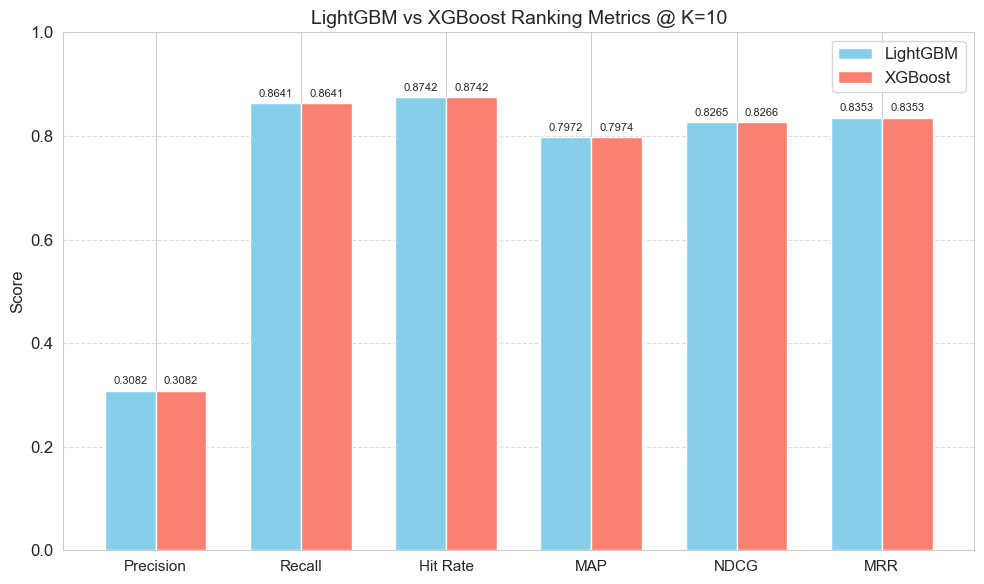

In [26]:
import matplotlib.pyplot as plt
import numpy as np

# Data
metrics = ['Precision', 'Recall', 'Hit Rate', 'MAP', 'NDCG', 'MRR']
lightgbm = [0.3082, 0.8641, 0.8742, 0.7972, 0.8265, 0.8353]
xgboost = [0.3082, 0.8641, 0.8742, 0.7974, 0.8266, 0.8353]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, lightgbm, width, label='LightGBM', color='skyblue')
rects2 = ax.bar(x + width/2, xgboost, width, label='XGBoost', color='salmon')

# Labels and formatting
ax.set_ylabel('Score', fontsize=12)
ax.set_title('LightGBM vs XGBoost Ranking Metrics @ K=10', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.set_ylim(0, 1)

# Add value labels on bars
for rect in rects1 + rects2:
    height = rect.get_height()
    ax.annotate(f'{height:.4f}',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()